# Practical Lab 1: Streaming Data for Predictive Maintenance with Linear Regression-Based Alerts

## Project Overview

This lab extends the Data Stream Visualization Workshop by adding regression-based anomaly detection to a robot monitoring pipeline.

Historical measurements for robot **RMBR4-2** will be retrieved from **Neon PostgreSQL** to train eight univariate linear regression models, one for each of **Axes #1–#8**, using time as the input.

We will analyze regression residuals to justify two deviation thresholds, **MinC** and **MaxC**, and a minimum continuous duration, **T**. These rules will identify sustained deviations above predicted values as **Alerts** or **Errors**.

Synthetic testing data will be generated using the historical training data’s metadata and statistics, then streamed into the database. An integrated dashboard will display measurements, regression predictions, and annotated events. Detected events will be stored for review.

## Implementation Approach

Reusable processing, modeling, streaming, and detection logic will be implemented in **Python classes within separate modules**. This notebook will call those classes and document the methods, outputs, and findings.

## 1. Project Setup

Import the libraries and existing project components needed to access the historical data.

The project uses `TelemetryStore` to communicate with Neon PostgreSQL and `JOINTS` to identify the eight axis columns consistently. The notebook runs from the project root so that the existing Python modules can be imported.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from acquisition.controller_feed import JOINTS
from persistence.telemetry_store import TelemetryStore

PROJECT_ROOT = Path.cwd()

assert (PROJECT_ROOT / "persistence").is_dir(), (
    "Run this notebook from the project root folder."
)

print("Project folder:", PROJECT_ROOT.name)
print("Axes:", JOINTS)

Project folder: DataStreamVisualization-regression-based-anomaly-detection
Axes: ['j1', 'j2', 'j3', 'j4', 'j5', 'j6', 'j7', 'j8']


## 2. Retrieve Historical Training Data from Neon

Retrieve the persisted historical records marked `origin = 'seed'` from Neon PostgreSQL and sort them chronologically.

These database records will form the training dataset for the regression models. Synthetic testing records will remain separate from the historical training data.

Before proceeding, check that the retrieved dataset:

- Is not empty.
- Contains valid, unique timestamps.
- Has no missing values in Axes #1–#8.
- Contains only historical seed records.

Display the sample count, time range, and first five rows to inspect the retrieved data.

In [2]:
# Retrieve historical training data from the cloud database.
store = TelemetryStore()

training_df = (
    store.wide(origin="seed")
    .sort_values("sampled_at")
    .reset_index(drop=True)
)

assert not training_df.empty, "No historical training data found in Neon."
assert training_df["sampled_at"].notna().all(), "Missing timestamps found."
assert not training_df["sampled_at"].duplicated().any(), (
    "Duplicate timestamps found."
)
assert training_df[JOINTS].notna().all().all(), "Missing axis values found."
assert training_df["origin"].eq("seed").all(), (
    "Training data contains records outside the historical seed data."
)

print("Training source: Neon PostgreSQL")
print(f"Historical samples: {len(training_df):,}")
print(f"Number of axes: {len(JOINTS)}")
print("First timestamp:", training_df["sampled_at"].min())
print("Last timestamp:", training_df["sampled_at"].max())

display(training_df.head())

Training source: Neon PostgreSQL
Historical samples: 39,672
Number of axes: 8
First timestamp: 2022-10-17 12:18:23.660000+00:00
Last timestamp: 2022-10-18 10:44:58.628000+00:00


,sample_id,sampled_at,trait,state,origin,j1,j2,j3,j4,j5,j6,j7,j8
0,1,2022-10-17 12:18:23.660000+00:00,current,IDLE,seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2022-10-17 12:18:25.472000+00:00,current,IDLE,seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2022-10-17 12:18:27.348000+00:00,current,IDLE,seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2022-10-17 12:18:29.222000+00:00,current,IDLE,seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2022-10-17 12:18:31.117000+00:00,current,IDLE,seed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Findings: Database Retrieval

Successfully retrieved **39,672 historical samples** from Neon PostgreSQL, covering **October 17–18, 2022**, with measurements for all eight axes.

The validation checks passed: timestamps are present and unique, axis values have no missing entries, and all retrieved records belong to the historical training dataset (`origin = 'seed'`).

The first five samples are marked `IDLE` and contain zero values across all eight axes. We will inspect the full dataset before deciding how to handle idle periods.

## 3. Inspect Training Data and Sampling Intervals

Use the `TrainingDataInspector` class to examine the historical data retrieved from Neon.

This inspection summarizes:

- Each axis’s distribution, missing values, infinite values, and proportion of zeros.
- The proportion of samples labeled `RUNNING` or `IDLE`.
- The timing between consecutive samples and any recording gaps longer than 10 seconds.

These results will guide preprocessing, synthetic data generation, and interpretation of regression residuals. Idle samples will remain in the dataset during this inspection.

Recording gaps require special attention because missing observations cannot establish that a deviation persisted continuously.

In [3]:
from analysis.training_inspector import TrainingDataInspector

inspector = TrainingDataInspector(training_df, JOINTS)

print("AXIS STATISTICS")
display(inspector.axis_summary().round(4))

print("RECORDED OPERATING STATES")
display(inspector.activity_summary().round(2))

print("SAMPLING INTERVALS")
display(inspector.sampling_summary().round(3))

print("RECORDING GAPS LONGER THAN 10 SECONDS")
display(inspector.recording_gaps())

AXIS STATISTICS


,count,missing_count,infinite_count,mean,std,min,q1,median,q3,max,zero_pct
j1,39672.0,0,0,0.7257,2.1621,0.0,0.0,0.0,0.3127,23.6093,65.3206
j2,39672.0,0,0,3.6134,6.8800,0.0,0.0,0.0,4.2172,51.7132,65.0887
j3,39672.0,0,0,2.7103,5.1119,0.0,0.0,0.0,4.5862,41.8556,65.1442
j4,39672.0,0,0,0.6202,1.5749,0.0,0.0,0.0,0.5162,15.6663,65.5475
j5,39672.0,0,0,0.9545,2.1002,0.0,0.0,0.0,0.8001,20.7508,65.1946
j6,39672.0,0,0,0.5994,1.8155,0.0,0.0,0.0,0.3613,20.9314,65.7214
j7,39672.0,0,0,0.8701,2.1668,0.0,0.0,0.0,0.3100,8.1085,65.5626
j8,39672.0,0,0,0.1022,0.4231,0.0,0.0,0.0,0.0785,5.9056,65.4315


RECORDED OPERATING STATES


,samples,percentage
state,,
IDLE,25487,64.24
RUNNING,14185,35.76


SAMPLING INTERVALS


,interval_count,minimum_seconds,median_seconds,mean_seconds,maximum_seconds,gaps_over_10_seconds
0,39671,1.714,1.891,2.037,402.538,6


RECORDING GAPS LONGER THAN 10 SECONDS


,previous_timestamp,next_timestamp,gap_seconds
0,2022-10-17 12:27:00.597000+00:00,2022-10-17 12:33:43.135000+00:00,402.538
1,2022-10-17 13:02:12.324000+00:00,2022-10-17 13:07:44.934000+00:00,332.610
2,2022-10-17 15:13:22.042000+00:00,2022-10-17 15:13:55.155000+00:00,33.113
3,2022-10-17 15:33:24.605000+00:00,2022-10-17 15:33:57.655000+00:00,33.050
4,2022-10-17 17:03:23.722000+00:00,2022-10-17 17:03:56.535000+00:00,32.813
5,2022-10-17 20:15:10.766000+00:00,2022-10-17 20:15:44.156000+00:00,33.390


### Findings: Training Data Inspection

All eight axes contain **39,672 measurements**, with no missing or infinite values. Their measurement ranges differ substantially: Axis #2 reaches approximately **51.71**, while Axis #8 reaches approximately **5.91**.

The operating-state labels identify **25,487 idle samples (64.24%)** and **14,185 running samples (35.76%)**. These labels were derived during ingestion from whether any axis measurement was nonzero; they are not independently measured machine states.

The median sampling interval is **1.891 seconds**. Six recording gaps exceed 10 seconds, with the largest lasting **402.538 seconds**.

For the initial required Time → Axis models, we will retain both idle and running samples and preserve the original measurements. Zero readings will not be treated as missing values, and large readings will not be removed merely because they are extreme. Residual analysis will assess the limitations of fitting a straight-line baseline to data containing operating cycles and idle periods.

Elapsed time will be calculated from actual timestamps. Recording gaps will remain visible rather than being filled with invented observations.

## 4. Prepare the Time Feature

Each required regression model will use a single input: **elapsed seconds since the first historical training timestamp**. Its target will be the corresponding axis measurement.

The `TimePreprocessor` class learns this reference timestamp from training data. The same fitted reference will later be applied to synthetic testing data, so training and prediction use a consistent time coordinate.

This step preserves the original axis values and timestamp spacing. Normalization and standardization will be handled separately using parameters fitted only on historical training data.

In [4]:
from analysis.time_preprocessor import TimePreprocessor

time_preprocessor = TimePreprocessor()
prepared_training_df = time_preprocessor.fit_transform(training_df)

# Confirm that preparation preserved all original axis measurements.
pd.testing.assert_frame_equal(
    prepared_training_df[JOINTS],
    training_df[JOINTS],
)

assert prepared_training_df["elapsed_seconds"].iloc[0] == 0
assert prepared_training_df["elapsed_seconds"].is_monotonic_increasing

print("Training reference:", time_preprocessor.reference_time_)
print(f"Prepared samples: {len(prepared_training_df):,}")
print(
    "Final elapsed time:",
    f"{prepared_training_df['elapsed_seconds'].iloc[-1]:,.3f} seconds",
)
print("Original axis measurements preserved: PASS")

display(
    prepared_training_df[
        ["sampled_at", "elapsed_seconds", *JOINTS]
    ].head()
)

Training reference: 2022-10-17 12:18:23.660000+00:00
Prepared samples: 39,672
Final elapsed time: 80,794.968 seconds
Original axis measurements preserved: PASS


,sampled_at,elapsed_seconds,j1,j2,j3,j4,j5,j6,j7,j8
0,2022-10-17 12:18:23.660000+00:00,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17 12:18:25.472000+00:00,1.812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17 12:18:27.348000+00:00,3.688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17 12:18:29.222000+00:00,5.562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17 12:18:31.117000+00:00,7.457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Findings: Time-Feature Preparation

Successfully created `elapsed_seconds` for all **39,672 historical samples**, using **2022-10-17 12:18:23.660 UTC** as the fixed training reference.

Elapsed time ranges from **0 to 80,794.968 seconds**. Checks confirmed chronological ordering and preservation of the original axis measurements.

The fitted time preprocessor will use this same reference when transforming synthetic testing data.

## 5. Fit Normalization and Standardization on Training Data

The axis measurements have different ranges and variability. We will create two separate scaled versions using the historical training data retrieved from Neon:

- **Min–Max normalization:** `(value − training minimum) / training range`.
- **Z-score standardization:** `(value − training mean) / training standard deviation`.

The `AxisScaler` class stores the training parameters and applies them without modification to subsequent datasets. The Z-score calculation uses population standard deviation (`ddof=0`); the earlier descriptive statistics used sample standard deviation (`ddof=1`).

The original measurements and elapsed-time feature remain available. Normalized and standardized values are dimensionless. Predictions and alert deviations will be interpreted in the original measurement units.

Testing values may fall outside the training Min–Max interval of `[0, 1]`. We will not clip them, because doing so could hide unusually large deviations. Testing data is also not expected to have a Z-score mean of zero or standard deviation of one when transformed using training parameters.

In [5]:
import numpy as np

from analysis.axis_scaler import AxisScaler

axis_scaler = AxisScaler(JOINTS)
axis_scaler.fit(prepared_training_df)

normalized_training_df = axis_scaler.transform(
    prepared_training_df,
    method="minmax",
)

standardized_training_df = axis_scaler.transform(
    prepared_training_df,
    method="zscore",
)

print("PARAMETERS FITTED ONLY ON HISTORICAL TRAINING DATA")
display(axis_scaler.parameters_.round(6))

scaling_checks = pd.DataFrame({
    "normalized_min": normalized_training_df[JOINTS].min(),
    "normalized_max": normalized_training_df[JOINTS].max(),
    "zscore_mean": standardized_training_df[JOINTS].mean(),
    "zscore_std": standardized_training_df[JOINTS].std(ddof=0),
})

print("TRAINING SCALING CHECKS")
display(scaling_checks.round(6))

# Confirm both representations recover the original axis values.
for method, scaled_frame in [
    ("minmax", normalized_training_df),
    ("zscore", standardized_training_df),
]:
    restored = axis_scaler.inverse_transform(scaled_frame, method)

    np.testing.assert_allclose(
        restored[JOINTS].to_numpy(),
        prepared_training_df[JOINTS].to_numpy(),
        rtol=1e-10,
        atol=1e-10,
    )

    pd.testing.assert_series_equal(
        scaled_frame["elapsed_seconds"],
        prepared_training_df["elapsed_seconds"],
    )

print("Both inverse transformations recover original values: PASS")
print("Elapsed-time feature preserved in both representations: PASS")

PARAMETERS FITTED ONLY ON HISTORICAL TRAINING DATA


,minimum,maximum,mean,std,range
j1,0.0,23.60930,0.725743,2.162093,23.60930
j2,0.0,51.71323,3.613374,6.879875,51.71323
j3,0.0,41.85556,2.710336,5.111836,41.85556
j4,0.0,15.66630,0.620222,1.574877,15.66630
j5,0.0,20.75076,0.954521,2.100159,20.75076
j6,0.0,20.93142,0.599427,1.815475,20.93142
j7,0.0,8.10848,0.870145,2.166783,8.10848
j8,0.0,5.90564,0.102214,0.423070,5.90564


TRAINING SCALING CHECKS


,normalized_min,normalized_max,zscore_mean,zscore_std
j1,0.0,1.0,0.0,1.0
j2,0.0,1.0,0.0,1.0
j3,0.0,1.0,-0.0,1.0
j4,0.0,1.0,0.0,1.0
j5,0.0,1.0,-0.0,1.0
j6,0.0,1.0,-0.0,1.0
j7,0.0,1.0,-0.0,1.0
j8,0.0,1.0,0.0,1.0


Both inverse transformations recover original values: PASS
Elapsed-time feature preserved in both representations: PASS


### Findings: Training Data Scaling

Min–Max normalization and Z-score standardization were successfully applied to all eight axes using parameters fitted exclusively on historical data retrieved from Neon.

Each normalized training axis spans **0–1**. Each standardized training axis has a mean approximately equal to **0** and a population standard deviation approximately equal to **1**.

Both inverse transformations recovered the original measurements within numerical tolerance. The elapsed-time feature was preserved.

These fitted scaling parameters will be reused for synthetic testing data without refitting. This completes training-scaler preparation; testing-data transformation remains pending.

## 6. Train Eight Time-Based Linear Regression Models

Fit one univariate linear regression for each of Axes #1–#8 using the historical data retrieved from Neon.

Each model has the form:

**Predicted axis value = intercept + slope × elapsed seconds**

The input is `elapsed_seconds`, and the target is the axis measurement in its original units. Both idle and running samples are retained.

Original-unit targets keep model coefficients, predictions, and residual thresholds directly interpretable. Normalized and standardized representations remain available for synthetic-data processing and comparison; they are separate representations, not transformations applied successively.

For each model, record the slope, intercept, and training R², MAE, and RMSE. These metrics describe the fit to historical training data; they do not establish performance on unseen testing data.

Scatter plots with fitted lines will show how well a straight-line time baseline represents the measurements. A time-only model may explain little of the variation caused by repeated motion cycles and idle periods. We will examine that limitation through the results and residual analysis.

These figures are model-analysis plots. The integrated monitoring dashboard will be implemented separately.

Models fitted: 8
Training samples per model: 39672
Input feature: elapsed_seconds
Target scale: original measurement units


,slope_per_second,intercept,training_r2,training_mae,training_rmse
axis,,,,,
j1,-1.17672857e-07,0.730542,0.000002,1.096748,2.162091
j2,2.19420342e-06,3.523886,0.000054,4.915121,6.879688
j3,-5.77718596e-07,2.733898,0.000007,3.647439,5.111819
j4,3.89003446e-07,0.604357,0.000033,0.883368,1.574851
j5,8.38117789e-08,0.951103,0.000001,1.340338,2.100159
j6,4.74445547e-07,0.580077,0.000037,0.877076,1.815442
j7,5.53718615e-07,0.847563,0.000035,1.334128,2.166746
j8,8.49998875e-08,0.098748,0.000022,0.143129,0.423065


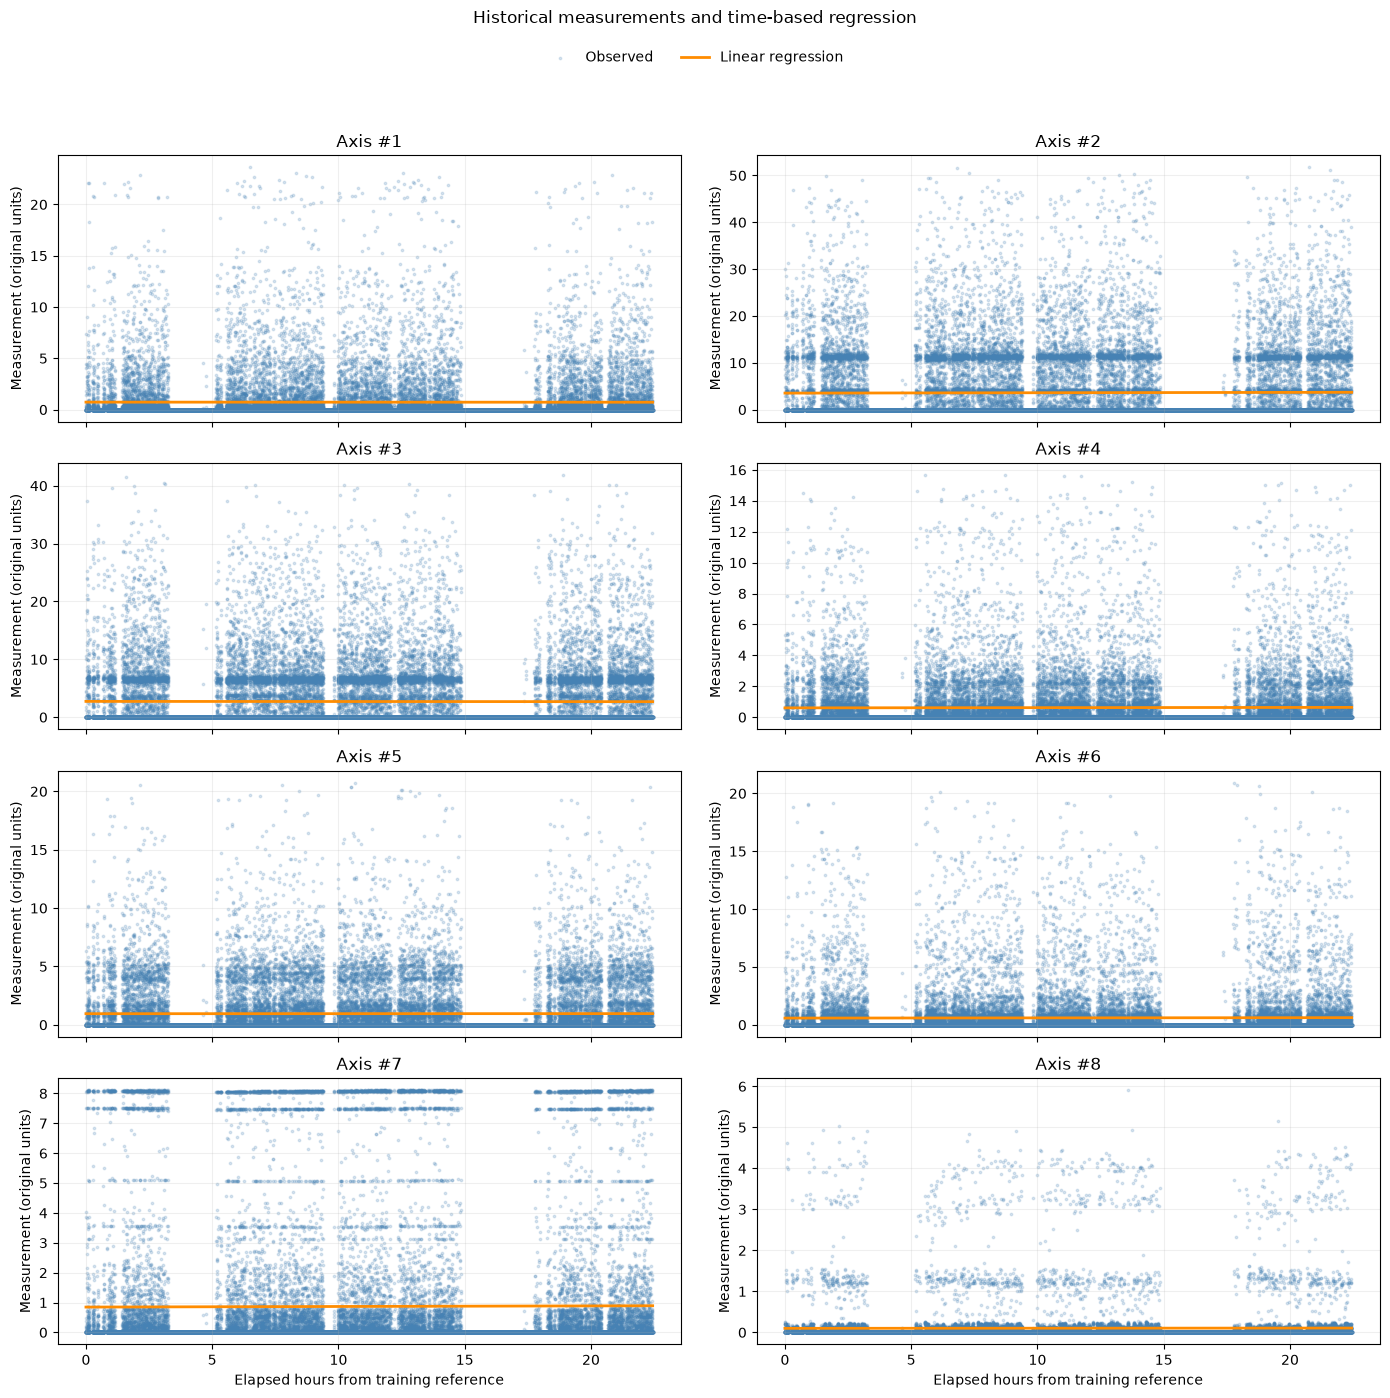

In [6]:
import matplotlib.pyplot as plt

from analysis.axis_regression import AxisRegression

regression = AxisRegression(JOINTS)
regression.fit(prepared_training_df)

training_predictions = regression.predict(prepared_training_df)

assert len(regression.models_) == 8
assert training_predictions.shape == (len(prepared_training_df), 8)
assert np.isfinite(training_predictions.to_numpy()).all()

print("Models fitted:", len(regression.models_))
print("Training samples per model:", len(prepared_training_df))
print("Input feature: elapsed_seconds")
print("Target scale: original measurement units")

display(
    regression.summary_.style.format({
        "slope_per_second": "{:.8e}",
        "intercept": "{:.6f}",
        "training_r2": "{:.6f}",
        "training_mae": "{:.6f}",
        "training_rmse": "{:.6f}",
    })
)

regression_figure = regression.plot_fits(prepared_training_df)
plt.show()

### Findings: Time-Based Regression Models

Eight separate linear regression models were fitted using **39,672 historical samples per axis**, retrieved from Neon PostgreSQL. Each model uses elapsed seconds as its only input. Slopes, intercepts, and training-fit metrics are recorded above.

All training R² values are close to zero. The largest is approximately **0.000054 for Axis #2**, corresponding to only **0.0054% of explained variation**. The fitted lines are nearly horizontal.

These results indicate that a straight-line time trend explains very little of the observed variation. The plots show substantial variation during active periods and many zero readings during idle periods, which a time-only linear model does not capture.

The models satisfy the required regression approach and provide baselines for residual analysis. However, their predictions should not be described as accurate estimates of individual operating-cycle measurements. Low R² does not establish whether the robot is healthy or faulty.

Next, we will examine residual distributions and sustained positive deviations to justify alert thresholds and duration rules. The metrics reported here are training diagnostics, not evaluations on unseen testing data.

`Next, we’ll calculate residuals = observed − predicted, examine their distributions, and compare outlier counts across the eight axes. This will provide evidence for choosing MinC, MaxC, and T.`

## 7. Analyze Regression Residuals

Calculate each residual as:

**Residual = observed axis measurement − regression prediction**

A positive residual indicates a measurement above the regression line. A negative residual indicates a measurement below it.

The `ResidualAnalyzer` class will:

- Summarize residual distributions for all eight axes.
- Calculate the 95th and 99th percentiles as exploratory reference values.
- Count observations above the upper Tukey fence, defined as `Q3 + 1.5 × IQR`.
- Compare residuals between idle and running states.
- Plot residual histograms and residuals over time.

The upper Tukey fence is a descriptive outlier rule, not a final alert threshold. A statistically unusual reading is not necessarily a mechanical fault. Likewise, percentiles describe deviation magnitudes but do not establish how long a deviation persists.

Histograms use a logarithmic count axis to make less frequent residual values visible alongside the many idle readings. No transformation is applied to the residual values themselves.

These are training residuals. Their mean is expected to be approximately zero because the fitted ordinary least-squares models include an intercept; this alone does not demonstrate good predictive performance.

In [7]:
from analysis.residual_analyzer import ResidualAnalyzer

residual_analyzer = ResidualAnalyzer(
    observations=prepared_training_df,
    predictions=training_predictions,
    axes=JOINTS,
)

training_residuals = residual_analyzer.residuals

print("RESIDUAL SUMMARY")
display(residual_analyzer.summary().round(6))

print("RESIDUALS BY OPERATING STATE")
display(residual_analyzer.state_summary().round(6))

# Verify that residuals reconstruct the original observations.
np.testing.assert_allclose(
    (training_predictions + training_residuals).to_numpy(),
    prepared_training_df[JOINTS].to_numpy(),
    rtol=1e-10,
    atol=1e-10,
)

print("Prediction + residual reconstructs observations: PASS")

RESIDUAL SUMMARY


,mean,std,minimum,median,q95,q99,maximum,upper_iqr_fence,above_upper_fence,above_upper_fence_pct
axis,,,,,,,,,,
j1,-0.0,2.162091,-0.730542,-0.723341,3.622423,10.637570,22.881511,0.051874,6500,16.384352
j2,0.0,6.879688,-3.701166,-3.562495,13.548942,27.827261,48.082660,7.041595,6894,17.377495
j3,0.0,5.111819,-2.733898,-2.698463,9.756149,22.004903,39.160990,8.756844,2311,5.825267
j4,0.0,1.574851,-0.635786,-0.611303,2.506291,7.724843,15.054179,0.685873,5604,14.125832
j5,-0.0,2.100159,-0.957874,-0.952580,4.106583,8.931155,19.796448,1.054121,6144,15.486993
j6,-0.0,1.815442,-0.618410,-0.588669,2.498980,9.737241,20.320990,0.335778,5317,13.402400
j7,-0.0,2.166746,-0.892300,-0.857640,7.175265,7.227199,7.260771,-0.069933,6594,16.621295
j8,0.0,0.423065,-0.105615,-0.100259,0.096614,2.866628,5.802731,0.097489,1942,4.895140


RESIDUALS BY OPERATING STATE


samples  mean_residual  median_residual  q95_residual
state   axis                                                       
IDLE    j1      25487      -0.725750        -0.725486     -0.721713
        j2      25487      -3.613238        -3.618160     -3.533858
        j3      25487      -2.710372        -2.709076     -2.690552
        j4      25487      -0.620198        -0.621070     -0.606125
        j5      25487      -0.954516        -0.954704     -0.951484
        j6      25487      -0.599398        -0.600462     -0.582234
        j7      25487      -0.870111        -0.871353     -0.850079
        j8      25487      -0.102209        -0.102400     -0.099134
RUNNING j1      14185       1.303997        -0.123125      7.874828
        j2      14185       6.492111         6.756605     22.711349
        j3      14185       4.869880         3.830092     18.470021
        j4      14185       1.114345         0.304904      5.722315
        j5      14185       1.715033         0.698263      6.944009
        j6      14185       1.076972         0.150753      6.811519
        j7      14185       1.563378        -0.162537      7.211345
        j8      14185       0.183645        -0.003438      1.215327

Prediction + residual reconstructs observations: PASS


### Residual Distribution and Time Plots

Inspect the histograms for asymmetry, concentrated values, and long positive tails. Use the time plots to identify changing spread, repeated patterns, and idle intervals.

Both views will help assess whether simple distribution-based thresholds are suitable. Final threshold selection must also consider continuous exceedance durations and performance on separate synthetic scenarios.

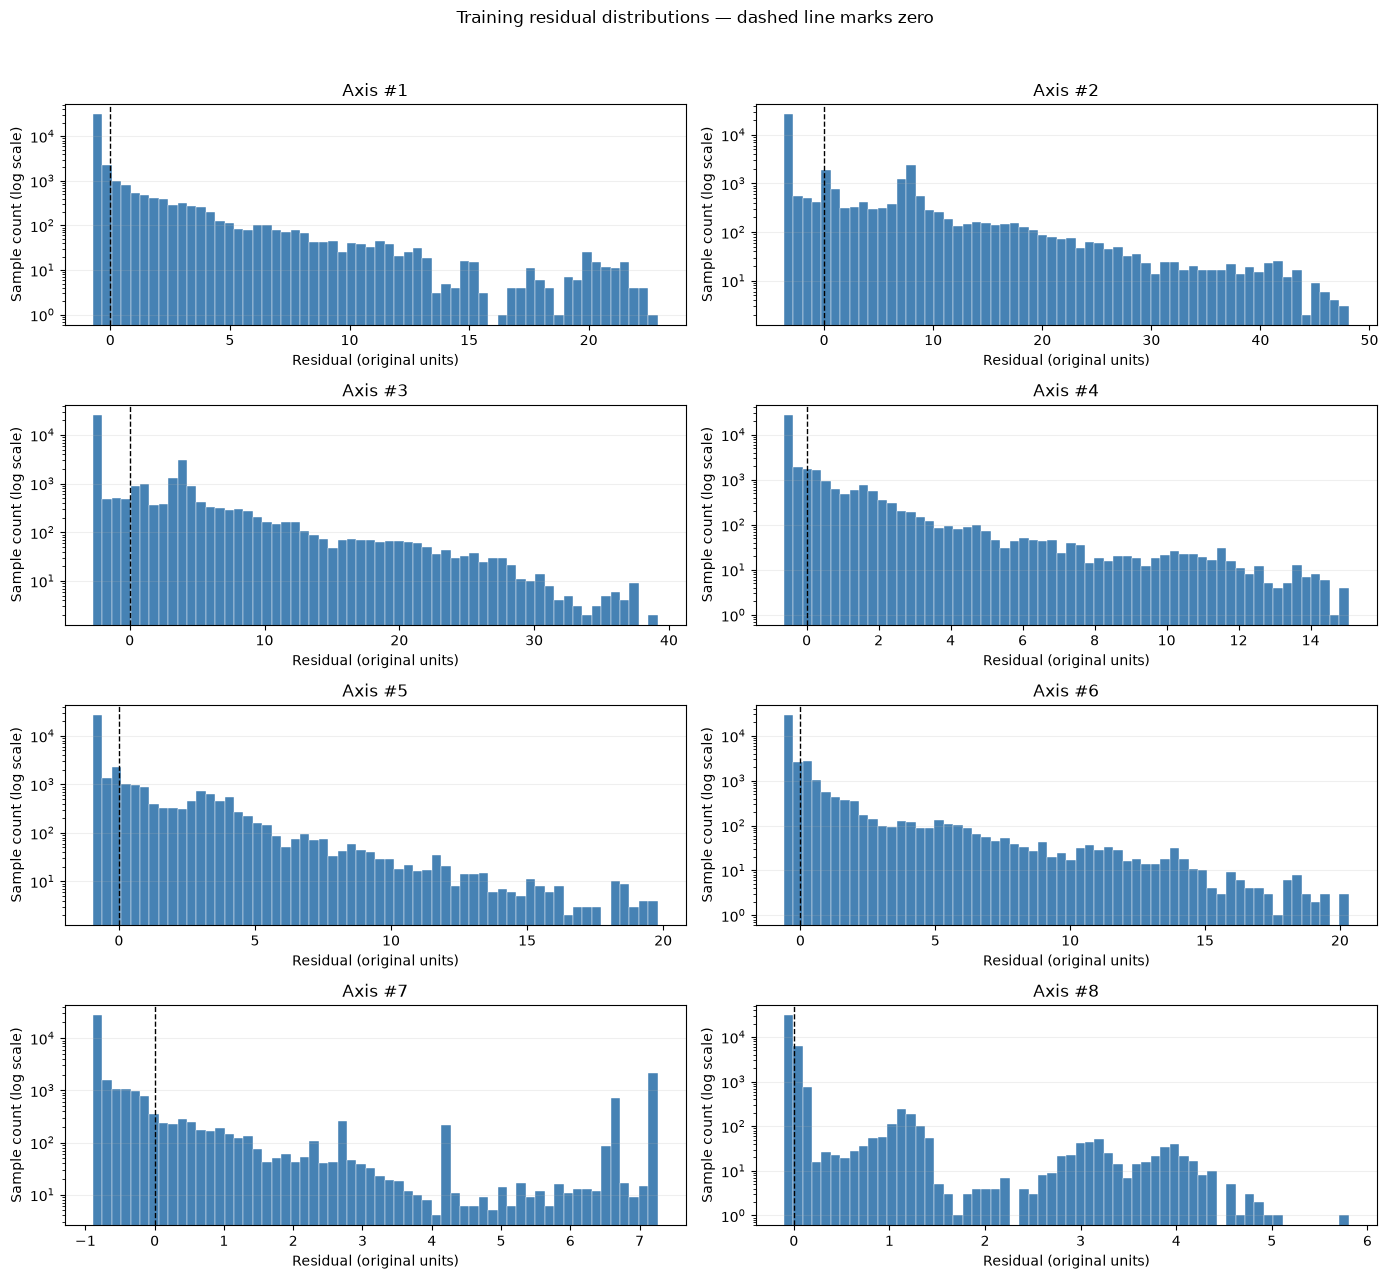

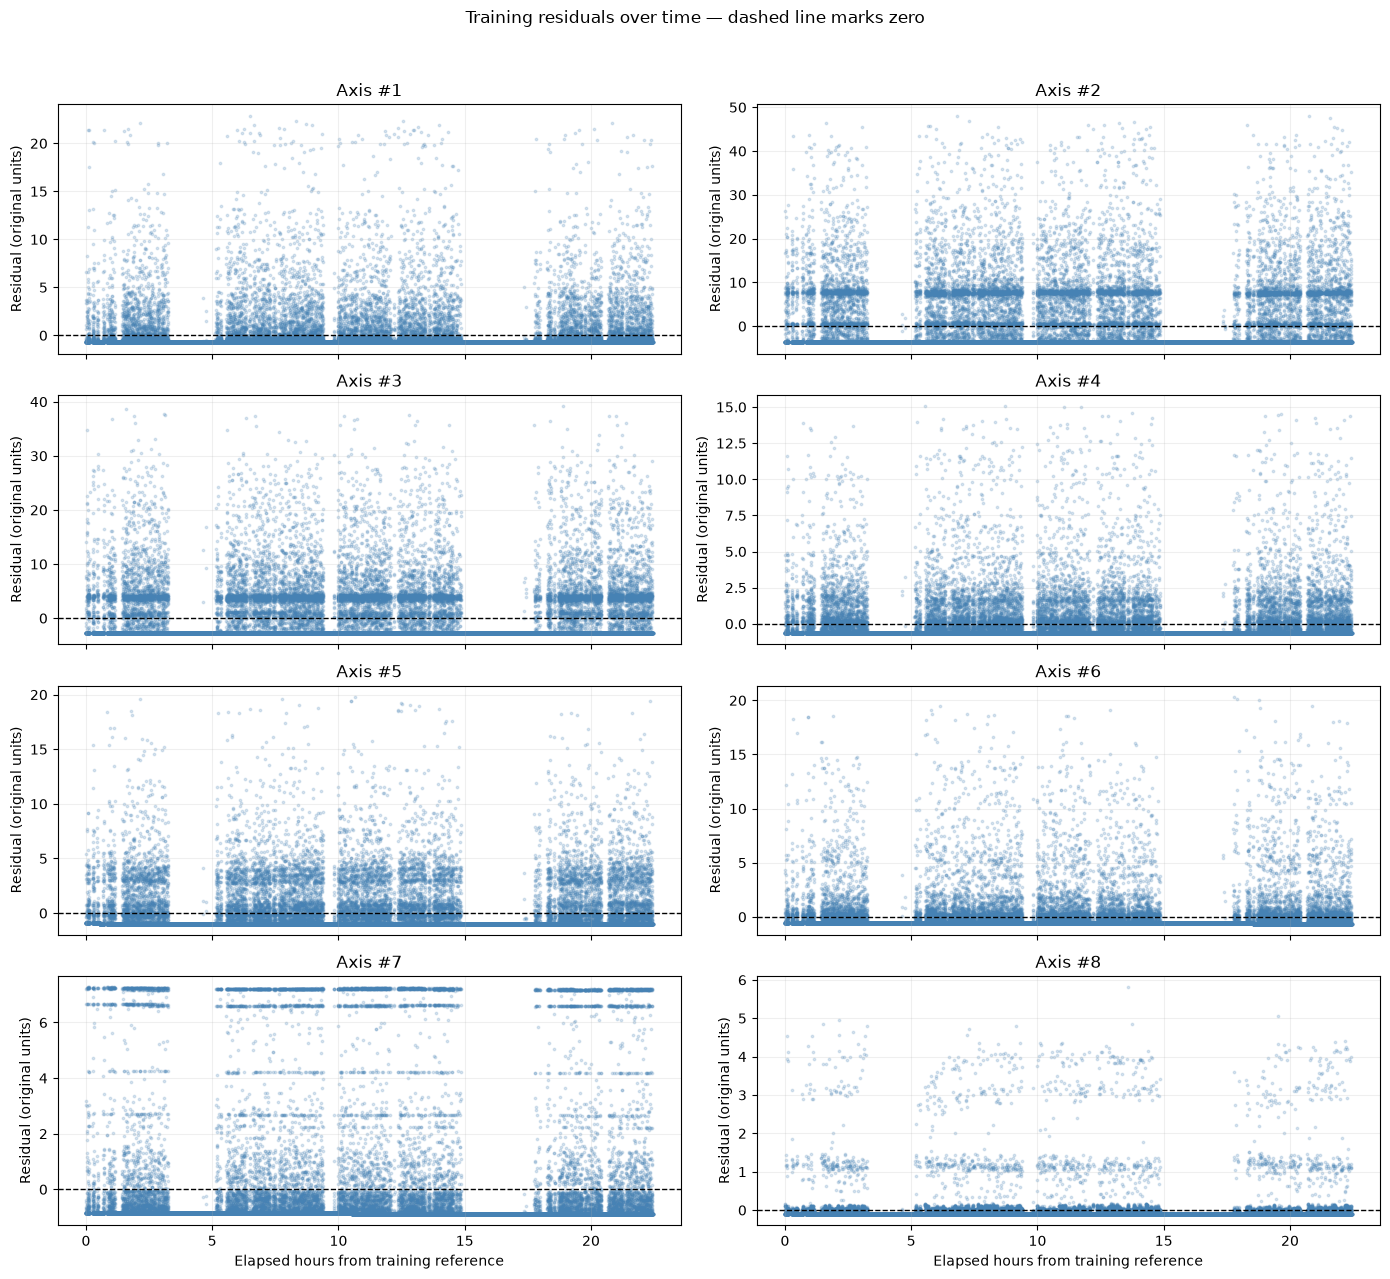

In [8]:
residual_distribution_figure = residual_analyzer.plot_distributions()
plt.show()

residual_time_figure = residual_analyzer.plot_over_time()
plt.show()

### Findings: Residual Analysis

Residuals were calculated for all eight axes, and the reconstruction check confirmed that **prediction + residual equals the original observation** within numerical tolerance.

The overall mean residual is approximately zero for every axis, as expected for ordinary least-squares regression with an intercept. However, the operating-state analysis reveals systematic differences: idle samples have negative mean residuals, while running samples have positive mean residuals. The fitted baseline therefore overpredicts idle measurements and underpredicts running measurements on average.

The histograms show asymmetric distributions and, for some axes, multiple concentrations of values. The time plots show structure associated with active and idle periods rather than an unstructured spread around zero. We should therefore not assume normally distributed residuals when choosing thresholds.

The upper IQR fence flags approximately **4.90%–17.38%** of samples per axis. These counts describe statistical exceedances, not verified mechanical faults. Axis #7 has a negative upper fence (**−0.069933**), demonstrating that this rule cannot be adopted directly as a positive-deviation alert threshold.

Residual magnitudes also differ substantially between axes. For example, the 99th percentile is approximately **27.83 for Axis #2** and **2.87 for Axis #8**, supporting investigation of axis-specific thresholds.

Axis #7’s 95th and 99th percentiles are close together (**7.175265 and 7.227199**), consistent with the concentration near its highest residual values. Percentile-based severity boundaries therefore require particular care for this axis.

Next, we will compare candidate thresholds and continuous exceedance durations. Historical exceedances will not be called false alarms without verified fault labels. Separate synthetic scenarios will help assess detection behavior.

**MinC, MaxC, and T have not yet been selected.**

## 8. Explore Candidate Thresholds and Continuous Durations

Compare the **95th, 97.5th, and 99th percentiles** of each axis’s historical residual distribution as candidate positive-deviation thresholds. These are exploratory candidates, not final MinC or MaxC values.

For each candidate, identify consecutive samples satisfying **residual ≥ threshold**. A run ends when a sample falls below the threshold or the gap between observations exceeds the permitted continuity limit.

Initially, set the continuity limit to **three times the median historical sampling interval**. This allows some timing variation while preventing long recording gaps from being counted as sustained exceedances. This is an operational assumption that will be reviewed separately from the alert duration T.

Measure each run from its first qualifying timestamp to its last qualifying timestamp. A single-sample run has zero observed duration. Compare how many runs last at least **4, 8, 12, and 20 seconds**. These candidate windows span approximately two to ten typical sampling intervals and allow investigation of the trade-off between suppressing short excursions and delaying detection.

The comparison uses historical training residuals and is exploratory. Historical exceedances are not verified faults or false alarms. Final settings will also require evaluation using separate synthetic scenarios, including sustained deviations and brief spikes.

In [9]:
from analysis.threshold_explorer import ThresholdExplorer

median_interval_seconds = (
    prepared_training_df["sampled_at"]
    .diff()
    .dt.total_seconds()
    .median()
)

candidate_max_gap_seconds = 3 * median_interval_seconds

threshold_explorer = ThresholdExplorer(
    observations=prepared_training_df,
    residuals=training_residuals,
    axes=JOINTS,
    max_gap_seconds=candidate_max_gap_seconds,
)

threshold_comparison = threshold_explorer.compare()

print(f"Median interval: {median_interval_seconds:.3f} seconds")
print(
    "Provisional continuity limit:",
    f"{candidate_max_gap_seconds:.3f} seconds",
)

actual_gaps = (
    prepared_training_df["sampled_at"]
    .diff()
    .dt.total_seconds()
)

print(
    "Recording intervals above this continuity limit:",
    int(actual_gaps.gt(candidate_max_gap_seconds).sum()),
)

print("CANDIDATE THRESHOLDS AND RUN DURATIONS")

with pd.option_context(
    "display.max_rows", 30,
    "display.max_columns", None,
):
    display(threshold_comparison.round(6))

Median interval: 1.891 seconds
Provisional continuity limit: 5.673 seconds
Recording intervals above this continuity limit: 701
CANDIDATE THRESHOLDS AND RUN DURATIONS


,axis,quantile,threshold,exceeding_samples,run_count,longest_run_seconds,runs_ge_4s,runs_ge_8s,runs_ge_12s,runs_ge_20s
0,j1,0.950,3.622423,1984,1814,7.403,5,0,0,0
1,j1,0.975,6.527079,992,956,5.547,2,0,0,0
2,j1,0.990,10.637570,397,397,0.000,0,0,0,0
3,j2,0.950,13.548942,1984,1700,5.649,1,0,0,0
4,j2,0.975,19.594129,992,918,3.828,0,0,0,0
5,j2,0.990,27.827261,397,396,1.924,0,0,0,0
6,j3,0.950,9.756149,1984,1768,11.279,6,1,0,0
7,j3,0.975,15.652730,992,920,3.913,0,0,0,0
8,j3,0.990,22.004903,397,384,1.954,0,0,0,0
9,j4,0.950,2.506291,1984,1827,3.965,0,0,0,0


### Findings: Initial Threshold and Duration Comparison

The candidate comparison shows that deviation magnitude and continuous duration must be considered together.

At the 95th-percentile threshold, Axis #8 produces 27 historical exceedance runs lasting at least 12 seconds and 12 lasting at least 20 seconds. Its longest run is 24.905 seconds. This threshold would generate substantially more historical events on Axis #8 than on the other axes.

At the 97.5th-percentile thresholds, the longest historical run across all axes is 5.592 seconds. At the 99th-percentile thresholds, the longest is 3.998 seconds. Therefore, an 8-second duration combined with these percentile thresholds is a candidate for suppressing the brief excursions observed in this training dataset.

This observation does not establish a false-alarm rate or prove that meaningful faults would be detected. The historical data has no verified fault labels, and these candidate settings were explored on training residuals.

The provisional continuity limit of 5.673 seconds is exceeded by 701 recording intervals. We will compare alternative continuity limits before accepting duration-based conclusions.

Axis #7 also requires special attention: its 97.5th-percentile threshold is 7.205220 and its 99th-percentile threshold is 7.227199. Their small separation may make severity classification sensitive to small measurement changes.

Final MinC, MaxC, and T values remain pending continuity sensitivity analysis and synthetic-scenario evaluation.

## 9. Check Sensitivity to the Continuity Limit

The initial analysis found 701 recording intervals above the provisional continuity limit of 5.673 seconds. We will inspect these intervals and compare three permitted gaps:

- **Two median intervals:** approximately 3.782 seconds.
- **Three median intervals:** approximately 5.673 seconds.
- **Four median intervals:** approximately 7.564 seconds.

For each setting, recompute exceedance runs using the same candidate residual thresholds. Compare the longest runs and the number lasting at least 8 seconds.

The thresholds remain unchanged so that differences reflect only the continuity assumption. A larger permitted gap may join observations into longer runs, but it cannot prove that the signal stayed above the threshold during an unobserved interval.

This sensitivity check will help determine whether the proposed duration rule depends strongly on the permitted sampling gap.

In [10]:
sampling_intervals = (
    prepared_training_df["sampled_at"]
    .diff()
    .dt.total_seconds()
    .dropna()
)

print("SAMPLING INTERVAL DISTRIBUTION")

display(
    sampling_intervals.quantile(
        [0.50, 0.90, 0.95, 0.975, 0.99, 0.999, 1.0]
    ).rename("interval_seconds").to_frame().round(3)
)

gap_rows = []
comparison_frames = []

for multiplier in (2, 3, 4):
    gap_limit = multiplier * median_interval_seconds

    explorer = ThresholdExplorer(
        observations=prepared_training_df,
        residuals=training_residuals,
        axes=JOINTS,
        max_gap_seconds=gap_limit,
    )

    comparison = explorer.compare(
        quantiles=(0.95, 0.975, 0.99),
        durations=(8,),
    )

    comparison["gap_multiplier"] = multiplier
    comparison_frames.append(comparison)

    gap_rows.append({
        "gap_multiplier": multiplier,
        "permitted_gap_seconds": gap_limit,
        "intervals_above_limit": int(
            sampling_intervals.gt(gap_limit).sum()
        ),
    })

gap_sensitivity = pd.DataFrame(gap_rows)
continuity_comparison = pd.concat(
    comparison_frames,
    ignore_index=True,
)

print("CONTINUITY SETTINGS")
display(gap_sensitivity.round(3))

print("LONGEST EXCEEDANCE RUNS: SECONDS")
display(
    continuity_comparison.pivot(
        index=["axis", "quantile"],
        columns="gap_multiplier",
        values="longest_run_seconds",
    )
    .rename(columns={
        2: "2x median gap",
        3: "3x median gap",
        4: "4x median gap",
    })
    .round(3)
)

print("NUMBER OF EXCEEDANCE RUNS LASTING AT LEAST 8 SECONDS")
display(
    continuity_comparison.pivot(
        index=["axis", "quantile"],
        columns="gap_multiplier",
        values="runs_ge_8s",
    )
    .rename(columns={
        2: "2x median gap",
        3: "3x median gap",
        4: "4x median gap",
    })
)

SAMPLING INTERVAL DISTRIBUTION


,interval_seconds
0.500,1.891
0.900,1.967
0.950,2.003
0.975,5.472
0.990,6.007
0.999,6.387
1.000,402.538


CONTINUITY SETTINGS


,gap_multiplier,permitted_gap_seconds,intervals_above_limit
0,2,3.782,1244
1,3,5.673,701
2,4,7.564,6


LONGEST EXCEEDANCE RUNS: SECONDS


gap_multiplier  2x median gap  3x median gap  4x median gap
axis quantile                                              
j1   0.950              3.968          7.403          9.777
     0.975              2.043          5.547          5.547
     0.990              0.000          0.000          0.000
j2   0.950              3.915          5.649          8.087
     0.975              3.828          3.828          6.058
     0.990              1.924          1.924          1.924
j3   0.950              5.842         11.279         11.279
     0.975              3.913          3.913          5.734
     0.990              1.954          1.954          1.954
j4   0.950              3.965          3.965          8.399
     0.975              2.156          2.156          2.156
     0.990              0.000          0.000          0.000
j5   0.950              3.985          7.563          8.015
     0.975              2.098          2.098          6.234
     0.990              1.992          1.992          1.992
j6   0.950              2.118          5.616          6.178
     0.975              2.018          5.592          5.680
     0.990              1.917          1.917          1.917
j7   0.950              3.998          9.481          9.536
     0.975              3.998          3.998          9.536
     0.990              3.998          3.998          5.823
j8   0.950             24.905         24.905         27.097
     0.975              2.140          2.140          2.140
     0.990              0.000          0.000          0.000

NUMBER OF EXCEEDANCE RUNS LASTING AT LEAST 8 SECONDS


gap_multiplier  2x median gap  3x median gap  4x median gap
axis quantile                                              
j1   0.950                  0              0              1
     0.975                  0              0              0
     0.990                  0              0              0
j2   0.950                  0              0              1
     0.975                  0              0              0
     0.990                  0              0              0
j3   0.950                  0              1              1
     0.975                  0              0              0
     0.990                  0              0              0
j4   0.950                  0              0              2
     0.975                  0              0              0
     0.990                  0              0              0
j5   0.950                  0              0              1
     0.975                  0              0              0
     0.990                  0              0              0
j6   0.950                  0              0              0
     0.975                  0              0              0
     0.990                  0              0              0
j7   0.950                  0              1              2
     0.975                  0              0              1
     0.990                  0              0              0
j8   0.950                 37             40             45
     0.975                  0              0              0
     0.990                  0              0              0

### Findings: Continuity Sensitivity

The median sampling interval is **1.891 seconds**, and the 95th percentile is **2.003 seconds**. However, the 97.5th and 99th percentiles are **5.472 and 6.007 seconds**, showing that the recording includes appreciably longer intervals. Their cause cannot be determined from timestamps alone.

Changing the permitted gap changes the number of intervals that break continuity:

- **3.782 seconds:** 1,244 intervals exceed the limit.
- **5.673 seconds:** 701 intervals exceed the limit.
- **7.564 seconds:** six intervals exceed the limit.

At the 97.5th-percentile residual thresholds, no runs reach eight seconds under the two stricter continuity settings. Under the most permissive setting, Axis #7 has one qualifying run lasting **9.536 seconds**. Therefore, the proposed eight-second rule is not completely insensitive to the continuity assumption.

At the 99th-percentile thresholds, no runs reach eight seconds under any tested setting. Axis #8’s 95th-percentile threshold produces **37–45 qualifying runs**, reinforcing that this lower threshold behaves differently for that axis.

A longer permitted gap joins more observations but provides no additional evidence about the signal between them. The continuity setting must reflect a documented monitoring assumption rather than being selected solely to eliminate historical events.

The initial **97.5th-percentile MinC, 99th-percentile MaxC, and eight-second T** remain candidates for synthetic evaluation. Axis #7’s narrow threshold separation and gap-sensitive run require particular attention. No final detection settings have been selected.

## 10. Generate a Synthetic Development Baseline

Generate synthetic measurements using the historical training data retrieved from Neon.

The generator samples contiguous blocks of **128 observations**, keeping the eight axis values together. This retains short sequences of operating behavior and relationships between axes within each sampled block. Block boundaries can introduce artificial transitions, and the method does not reproduce the complete production schedule.

Apply small positive multiplicative perturbations with a lognormal parameter of **0.02** and an expected multiplier of one. This changes nonzero measurements while preserving zero readings. The parameter controls simulation variability; it is not an estimated sensor-accuracy specification.

Use a fixed random seed of **42** for reproducibility and generate **39,672 samples** at two-second intervals. Synthetic timestamps begin after the historical recording ends. The regular cadence is an intentional simulation choice; recording-gap scenarios will be introduced separately.

This dataset is a development baseline with no deliberately injected faults. It is not certified healthy data, because the source recording has no verified fault labels. We will compare its means, standard deviations, and zero proportions with the historical data before adding labeled deviations.

The regression models remain fitted on historical data. Predictions beyond the historical time range will be extrapolations, whose limitations must be considered.

The final evaluation dataset will use a separate random seed after detection settings are fixed. Both datasets will still share the same training-derived generation method and therefore cannot establish real-world generalization.

In [11]:
from analysis.synthetic_generator import SyntheticDataGenerator

synthetic_generator = SyntheticDataGenerator(
    axes=JOINTS,
    block_size=128,
    relative_noise=0.02,
).fit(prepared_training_df)

development_baseline = synthetic_generator.generate(
    n_samples=len(prepared_training_df),
    seed=42,
    interval_seconds=2.0,
)

# Apply the already-fitted time reference and axis scalers.
prepared_development_baseline = time_preprocessor.transform(
    development_baseline
)

normalized_development_baseline = axis_scaler.transform(
    prepared_development_baseline,
    method="minmax",
)

standardized_development_baseline = axis_scaler.transform(
    prepared_development_baseline,
    method="zscore",
)

assert len(development_baseline) == 39672
assert not development_baseline["sampled_at"].duplicated().any()
assert np.isfinite(development_baseline[JOINTS].to_numpy()).all()
assert development_baseline[JOINTS].ge(0).all().all()

print("Synthetic development samples:", len(development_baseline))
print("First timestamp:", development_baseline["sampled_at"].min())
print("Last timestamp:", development_baseline["sampled_at"].max())
print(
    "Synthetic idle percentage:",
    round(development_baseline["state"].eq("IDLE").mean() * 100, 2),
)

print("HISTORICAL VS SYNTHETIC BASELINE")
display(synthetic_generator.compare(development_baseline).round(4))

print("SYNTHETIC VALUES SCALED WITH HISTORICAL PARAMETERS")
display(pd.DataFrame({
    "normalized_min": normalized_development_baseline[JOINTS].min(),
    "normalized_max": normalized_development_baseline[JOINTS].max(),
    "zscore_mean": standardized_development_baseline[JOINTS].mean(),
    "zscore_std": standardized_development_baseline[JOINTS].std(ddof=0),
}).round(4))

print("Synthetic baseline validation: PASS")

Synthetic development samples: 39672
First timestamp: 2022-10-18 10:45:00.628000+00:00
Last timestamp: 2022-10-19 08:47:22.628000+00:00
Synthetic idle percentage: 65.66
HISTORICAL VS SYNTHETIC BASELINE


,training_mean,synthetic_mean,training_std,synthetic_std,training_zero_pct,synthetic_zero_pct,mean_change_pct,std_change_pct
j1,0.7257,0.6990,2.1621,2.1207,65.3206,66.6767,-3.6849,-1.9159
j2,3.6134,3.4797,6.8799,6.8085,65.0887,66.4600,-3.6981,-1.0373
j3,2.7103,2.6081,5.1118,5.0725,65.1442,66.5381,-3.7723,-0.7688
j4,0.6202,0.5982,1.5749,1.5587,65.5475,66.9036,-3.5557,-1.0292
j5,0.9545,0.9200,2.1002,2.0874,65.1946,66.5684,-3.6199,-0.6076
j6,0.5994,0.5723,1.8155,1.7553,65.7214,67.0750,-4.5200,-3.3172
j7,0.8701,0.8407,2.1668,2.1391,65.5626,66.9339,-3.3861,-1.2787
j8,0.1022,0.0966,0.4231,0.4089,65.4315,66.7599,-5.5313,-3.3507


SYNTHETIC VALUES SCALED WITH HISTORICAL PARAMETERS


,normalized_min,normalized_max,zscore_mean,zscore_std
j1,0.0,1.0167,-0.0124,0.9808
j2,0.0,0.9984,-0.0194,0.9896
j3,0.0,1.0053,-0.0200,0.9923
j4,0.0,1.0347,-0.0140,0.9897
j5,0.0,1.0221,-0.0165,0.9939
j6,0.0,1.0070,-0.0149,0.9668
j7,0.0,1.0594,-0.0136,0.9872
j8,0.0,1.0626,-0.0134,0.9665


Synthetic baseline validation: PASS


### Findings: Synthetic Development Baseline

Generated **39,672 synthetic samples** at two-second intervals, covering **2022-10-18 10:45:00.628 UTC to 2022-10-19 08:47:22.628 UTC**. Validation confirmed unique timestamps and finite, nonnegative axis measurements.

Compared with the historical training data, synthetic axis means are approximately **3.39%–5.53% lower**, and population standard deviations are approximately **0.61%–3.35% lower**. The synthetic idle proportion is **65.66%**, compared with **64.24%** historically.

These differences are consistent with variability introduced by block sampling and perturbation. We retain this reproducible baseline without forcing its statistics to match the historical data exactly.

Normalization and standardization used the previously fitted historical parameters without refitting. Some normalized maxima exceed one, while standardized means and standard deviations differ from zero and one. These results are expected when transforming a new dataset using training parameters.

This baseline contains no deliberately injected faults, but it is not certified healthy. Matching means and standard deviations does not establish realistic temporal behavior or real-world detection accuracy. Labeled development scenarios and a separate final synthetic evaluation remain pending.

## 11. Predict the Synthetic Development Baseline

Apply the eight previously fitted regression models to the synthetic development baseline without retraining.

Synthetic timestamps have already been converted to elapsed seconds using the original training reference. Predictions and residuals remain in the original measurement units.

Because these timestamps occur after the historical recording, the predictions are extrapolations. Inspect their ranges and check whether any predictions are negative.

Before introducing deliberate anomalies, count sustained baseline exceedances using the historical 97.5th- and 99th-percentile residual thresholds, an eight-second candidate duration, and the provisional 5.673-second continuity limit.

These settings remain provisional. Baseline exceedances are not confirmed faults or verified false alarms. Thresholds must not be recalculated from the synthetic testing data.

In [12]:
# Predict using the existing historical models. Do not call fit() again.
development_predictions = regression.predict(
    prepared_development_baseline
)

assert development_predictions.shape == (
    len(prepared_development_baseline),
    len(JOINTS),
)
assert np.isfinite(development_predictions.to_numpy()).all()

# Confirm the prediction equation independently for every axis.
for axis in JOINTS:
    expected = (
        regression.summary_.loc[axis, "intercept"]
        + regression.summary_.loc[axis, "slope_per_second"]
        * prepared_development_baseline["elapsed_seconds"]
    )

    np.testing.assert_allclose(
        development_predictions[axis],
        expected,
        rtol=1e-10,
        atol=1e-10,
    )

development_residual_analyzer = ResidualAnalyzer(
    observations=prepared_development_baseline,
    predictions=development_predictions,
    axes=JOINTS,
)

development_baseline_residuals = (
    development_residual_analyzer.residuals
)

prediction_summary = pd.DataFrame({
    "observed_mean": prepared_development_baseline[JOINTS].mean(),
    "prediction_min": development_predictions.min(),
    "prediction_max": development_predictions.max(),
    "negative_predictions": development_predictions.lt(0).sum(),
    "mean_residual": development_baseline_residuals.mean(),
    "baseline_mae": development_baseline_residuals.abs().mean(),
    "baseline_rmse": np.sqrt(
        development_baseline_residuals.pow(2).mean()
    ),
})

print("Synthetic samples predicted:", len(development_predictions))
print("Models used:", len(regression.models_))
print("Prediction equation verification: PASS")

display(prediction_summary.round(6))

Synthetic samples predicted: 39672
Models used: 8
Prediction equation verification: PASS


,observed_mean,prediction_min,prediction_max,negative_predictions,mean_residual,baseline_mae,baseline_rmse
j1,0.699000,0.711698,0.721034,0,-0.017366,1.077089,2.120760
j2,3.479749,3.701171,3.875263,0,-0.308468,4.946914,6.815037
j3,2.608095,2.641383,2.687220,0,-0.056206,3.599122,5.073119
j4,0.598169,0.635787,0.666651,0,-0.053051,0.890742,1.559438
j5,0.919968,0.957874,0.964524,0,-0.041231,1.331489,2.087784
j6,0.572333,0.618411,0.656055,0,-0.064900,0.886472,1.756368
j7,0.840681,0.892301,0.936235,0,-0.073587,1.350145,2.140269
j8,0.096561,0.105616,0.112360,0,-0.012427,0.144741,0.409069


### Baseline Exceedances Before Anomaly Injection

Apply candidate thresholds calculated from historical training residuals to the synthetic baseline.

Count qualifying runs separately for each threshold. Counts at the higher threshold are not necessarily separate events from those at the lower threshold; severity handling will be defined in the streaming detector.

This comparison establishes baseline behavior before deliberate anomaly injection and helps prevent attributing every later detection to an injected scenario.

In [13]:
# Derive candidate thresholds from HISTORICAL residuals only.
candidate_thresholds = pd.DataFrame({
    "candidate_MinC": training_residuals.quantile(0.975),
    "candidate_MaxC": training_residuals.quantile(0.99),
})

candidate_T_seconds = 8.0

baseline_explorer = ThresholdExplorer(
    observations=prepared_development_baseline,
    residuals=development_baseline_residuals,
    axes=JOINTS,
    max_gap_seconds=candidate_max_gap_seconds,
)

baseline_rows = []

for axis in JOINTS:
    min_c = float(candidate_thresholds.loc[axis, "candidate_MinC"])
    max_c = float(candidate_thresholds.loc[axis, "candidate_MaxC"])

    assert 0 < min_c < max_c

    min_runs = baseline_explorer.exceedance_runs(axis, min_c)
    max_runs = baseline_explorer.exceedance_runs(axis, max_c)

    baseline_rows.append({
        "axis": axis,
        "candidate_MinC": min_c,
        "candidate_MaxC": max_c,
        "MinC_runs_ge_8s": int(
            min_runs["duration_seconds"].ge(candidate_T_seconds).sum()
        ),
        "MaxC_runs_ge_8s": int(
            max_runs["duration_seconds"].ge(candidate_T_seconds).sum()
        ),
        "longest_MinC_run_seconds": (
            min_runs["duration_seconds"].max()
            if not min_runs.empty else 0.0
        ),
        "longest_MaxC_run_seconds": (
            max_runs["duration_seconds"].max()
            if not max_runs.empty else 0.0
        ),
    })

baseline_detection_summary = pd.DataFrame(
    baseline_rows
).set_index("axis")

print("Threshold source: historical training residuals")
print("Candidate duration:", candidate_T_seconds, "seconds")
print("Continuity limit:", candidate_max_gap_seconds, "seconds")

display(baseline_detection_summary.round(6))

Threshold source: historical training residuals
Candidate duration: 8.0 seconds
Continuity limit: 5.673 seconds


,candidate_MinC,candidate_MaxC,MinC_runs_ge_8s,MaxC_runs_ge_8s,longest_MinC_run_seconds,longest_MaxC_run_seconds
axis,,,,,,
j1,6.527079,10.637570,0,0,2.0,0.0
j2,19.594129,27.827261,0,0,4.0,2.0
j3,15.652730,22.004903,0,0,4.0,2.0
j4,4.540263,7.724843,0,0,2.0,0.0
j5,5.660199,8.931155,0,0,2.0,2.0
j6,5.621047,9.737241,0,0,2.0,2.0
j7,7.205220,7.227199,0,0,4.0,4.0
j8,1.114214,2.866628,0,0,2.0,0.0


### Findings: Synthetic Baseline Predictions

The eight historical regression models successfully generated predictions for **39,672 synthetic development samples** without retraining. An independent equation check confirmed that predictions match the recorded slopes and intercepts.

All predictions were finite and nonnegative over the evaluated synthetic time range. Mean residuals were slightly negative for all axes, indicating that predictions exceeded synthetic observations on average. These results are consistent with the synthetic baseline’s lower mean measurements and the extrapolated regression lines.

Using historical 97.5th-percentile and 99th-percentile residual thresholds, an eight-second candidate duration, and a 5.673-second continuity limit, no synthetic baseline exceedance runs qualified. The longest run at either candidate threshold was four seconds.

This establishes baseline behavior for this development realization only. It does not prove a zero false-alarm rate or demonstrate anomaly-detection sensitivity. The next step is to introduce labeled deviations and evaluate whether sustained scenarios are detected while brief or interrupted excursions are handled correctly.

Final thresholds remain provisional.

## 12. Construct Labeled Development Scenarios

Create four controlled scenarios on each of the eight axes:

1. A four-second deviation above the candidate MaxC.
2. A twenty-second deviation between the candidate MinC and MaxC.
3. A twenty-second deviation above the candidate MaxC.
4. Two six-second above-MaxC segments separated by an eight-second recording gap.

Measurements within these scenarios are constructed as **prediction + target residual**. Moderate residuals use the midpoint between the candidate thresholds. High residuals use 110% of the candidate MaxC.

The observations immediately before and after each scenario are set to their regression predictions to isolate the scenario. The remaining baseline measurements are preserved, except for the three removed timestamps used to create the recording gap. Operating-state labels are recalculated after modification.

Scenario labels are stored separately from the measurement data and will not be supplied as model inputs.

These threshold-relative scenarios verify duration, severity, and gap-handling behavior. They are not independent evidence of threshold quality or physically realistic faults. In particular, Axis #7’s narrow moderate-deviation band makes its Alert-only scenario a precision check rather than evidence of meaningful mechanical severity separation.

Broader synthetic evaluation and final threshold justification remain necessary.

In [15]:
from analysis.scenario_injector import ScenarioInjector

scenario_injector = ScenarioInjector(JOINTS)

development_scenarios, development_scenario_labels = (
    scenario_injector.inject(
        baseline=prepared_development_baseline,
        predictions=development_predictions,
        thresholds=candidate_thresholds,
    )
)

# Recompute predictions after row removal to preserve exact alignment.
scenario_predictions = regression.predict(development_scenarios)

scenario_residuals = (
    development_scenarios[JOINTS] - scenario_predictions
)

# Check that each retained scenario observation has its intended residual.
for case in development_scenario_labels.itertuples(index=False):
    mask = development_scenarios["sampled_at"].between(
        case.start, case.end
    )

    assert int(mask.sum()) == case.observed_samples

    np.testing.assert_allclose(
        scenario_residuals.loc[mask, case.axis],
        case.target_residual,
        rtol=1e-10,
        atol=1e-10,
    )

assert np.isfinite(development_scenarios[JOINTS].to_numpy()).all()
assert development_scenarios[JOINTS].ge(0).all().all()

print("Development samples after gap insertion:", len(development_scenarios))
print("Labeled cases:", len(development_scenario_labels))
print("Scenario residual and sample-count checks: PASS")

print("SCENARIO LABELS")
with pd.option_context("display.max_rows", 40):
    display(
        development_scenario_labels.style.format({
            "span_seconds": "{:.1f}",
            "target_residual": "{:.6f}",
            "observed_samples": "{:d}",
            "longest_segment_seconds": "{:.1f}",
        })
    )

print("INSERTED RECORDING GAP")
display(
    TrainingDataInspector(
        development_scenarios, JOINTS
    ).recording_gaps(cutoff_seconds=candidate_max_gap_seconds)
)

Development samples after gap insertion: 39669
Labeled cases: 32
Scenario residual and sample-count checks: PASS
SCENARIO LABELS


,scenario,axis,start,end,span_seconds,target_residual,observed_samples,longest_segment_seconds
0,brief_high,j1,2022-10-18 10:48:20.628000+00:00,2022-10-18 10:48:24.628000+00:00,4.0,11.701327,3,4.0
1,sustained_moderate,j1,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,8.582325,11,20.0
2,sustained_high,j1,2022-10-18 10:55:00.628000+00:00,2022-10-18 10:55:20.628000+00:00,20.0,11.701327,11,20.0
3,gap_interrupted_high,j1,2022-10-18 10:58:20.628000+00:00,2022-10-18 10:58:40.628000+00:00,20.0,11.701327,8,6.0
4,brief_high,j2,2022-10-18 10:48:20.628000+00:00,2022-10-18 10:48:24.628000+00:00,4.0,30.609987,3,4.0
5,sustained_moderate,j2,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,23.710695,11,20.0
6,sustained_high,j2,2022-10-18 10:55:00.628000+00:00,2022-10-18 10:55:20.628000+00:00,20.0,30.609987,11,20.0
7,gap_interrupted_high,j2,2022-10-18 10:58:20.628000+00:00,2022-10-18 10:58:40.628000+00:00,20.0,30.609987,8,6.0
8,brief_high,j3,2022-10-18 10:48:20.628000+00:00,2022-10-18 10:48:24.628000+00:00,4.0,24.205393,3,4.0
9,sustained_moderate,j3,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,18.828816,11,20.0


INSERTED RECORDING GAP


,previous_timestamp,next_timestamp,gap_seconds
0,2022-10-18 10:58:26.628000+00:00,2022-10-18 10:58:34.628000+00:00,8.0


### Findings: Controlled Scenario Construction

Successfully constructed **32 labeled cases**, comprising four scenarios for each of eight axes. Removing three observations to introduce a recording gap reduced the dataset from **39,672 to 39,669 samples**.

Validation confirmed that each retained scenario measurement has its intended residual and that observed sample counts match the scenario definitions.

The gap-interrupted scenario contains an eight-second interval from **10:58:26.628 to 10:58:34.628 UTC**. Its overall span is twenty seconds, but its two observed exceedance segments each last only six seconds. Under the provisional 5.673-second continuity limit, these segments must remain separate.

With the candidate eight-second duration, brief and gap-interrupted scenarios should not qualify. Sustained moderate scenarios should meet the Alert rule, while sustained high scenarios should meet the Error rule and also satisfy the lower Alert condition.

These are expected outcomes, not yet verified detector results. The next task is to implement the streaming detector and compare its actual behavior against these expectations.

## 13. Implement Streaming Alert and Error Detection

The `StreamingAnomalyDetector` processes residuals one timestamped reading at a time. Each axis has independent timers for the candidate MinC and MaxC thresholds.

A timer starts at the first qualifying observation. It triggers an event when the elapsed duration reaches or exceeds T. Falling below its threshold resets that timer. A recording gap larger than the permitted continuity limit resets both timers before the new observation is processed.

The comparisons are inclusive: **residual ≥ threshold** and **elapsed duration ≥ T**.

A sustained high deviation satisfies both threshold rules, so Alert and Error records may overlap. These are separate rule events, not necessarily separate physical incidents. The highest active severity takes precedence in the displayed axis status.

Each event records its axis, severity, threshold, start, trigger time, last qualifying timestamp, duration, peak residual, and closure reason. Events are maintained in memory in this step; persistent logging will be added separately.

The detector uses measurement timestamps, so replay speed does not change event durations. It does not receive scenario labels.

In [16]:
from analysis.streaming_detector import StreamingAnomalyDetector

detector = StreamingAnomalyDetector(
    thresholds=candidate_thresholds,
    duration_seconds=candidate_T_seconds,
    max_gap_seconds=candidate_max_gap_seconds,
)

# Feed each observation sequentially, without using scenario labels.
for timestamp, values in zip(
    development_scenarios["sampled_at"],
    scenario_residuals[JOINTS].to_numpy(),
):
    active_status = detector.update(
        timestamp,
        dict(zip(JOINTS, values)),
    )

detector.finish()
development_events = detector.event_frame()

print("Processed readings:", len(development_scenarios))
print("Recorded threshold events:", len(development_events))

display(
    development_events.groupby(
        ["axis", "severity"]
    ).size().unstack(fill_value=0)
)

display(development_events.head(8))

Processed readings: 39669
Recorded threshold events: 24


severity,Alert,Error
axis,,
j1,2,1
j2,2,1
j3,2,1
j4,2,1
j5,2,1
j6,2,1
j7,2,1
j8,2,1


,event_id,axis,severity,threshold,start,triggered_at,end,duration_seconds,peak_residual,status,close_reason
0,1,j1,Alert,6.527079,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,8.582325,closed,below_threshold
1,2,j2,Alert,19.594129,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,23.710695,closed,below_threshold
2,3,j3,Alert,15.652730,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,18.828816,closed,below_threshold
3,4,j4,Alert,4.540263,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,6.132553,closed,below_threshold
4,5,j5,Alert,5.660199,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,7.295677,closed,below_threshold
5,6,j6,Alert,5.621047,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,7.679144,closed,below_threshold
6,7,j7,Alert,7.205220,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,7.216209,closed,below_threshold
7,8,j8,Alert,1.114214,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,1.990421,closed,below_threshold


### Verify Detection Against Controlled Scenario Labels

Compare detected events with the separately stored scenario labels.

Expected rule-event counts per axis are:

- Brief high deviation: zero Alerts and zero Errors.
- Sustained moderate deviation: one Alert and zero Errors.
- Sustained high deviation: one Alert and one Error.
- Gap-interrupted high deviation: zero Alerts and zero Errors.

With two-second sampling and T = eight seconds, the sustained scenarios should trigger exactly eight seconds after their start. Their final observed durations should be twenty seconds.

These checks verify the controlled scenarios. Additional boundary and escalation checks, independent synthetic evaluation, and persistent logging remain pending.

In [17]:
expected_counts = {
    "brief_high": (0, 0),
    "sustained_moderate": (1, 0),
    "sustained_high": (1, 1),
    "gap_interrupted_high": (0, 0),
}

verification_rows = []
matched_event_ids = set()

for case in development_scenario_labels.itertuples(index=False):
    matches = development_events.loc[
        development_events["axis"].eq(case.axis)
        & development_events["start"].between(case.start, case.end)
    ]

    actual_alerts = int(matches["severity"].eq("Alert").sum())
    actual_errors = int(matches["severity"].eq("Error").sum())
    expected_alerts, expected_errors = expected_counts[case.scenario]

    passed = (
        actual_alerts == expected_alerts
        and actual_errors == expected_errors
    )

    if not matches.empty:
        delays = (
            matches["triggered_at"] - case.start
        ).dt.total_seconds()

        passed = (
            passed
            and matches["start"].eq(case.start).all()
            and delays.eq(8.0).all()
            and matches["duration_seconds"].eq(20.0).all()
            and matches["close_reason"].eq("below_threshold").all()
        )

    matched_event_ids.update(matches["event_id"])

    verification_rows.append({
        "scenario": case.scenario,
        "axis": case.axis,
        "Alerts": actual_alerts,
        "Errors": actual_errors,
        "passed": bool(passed),
    })

scenario_verification = pd.DataFrame(verification_rows)

unmatched_events = development_events.loc[
    ~development_events["event_id"].isin(matched_event_ids)
]

display(scenario_verification)
print("Events outside labeled scenarios:", len(unmatched_events))

assert scenario_verification["passed"].all(), (
    "One or more controlled scenarios failed."
)
assert unmatched_events.empty, "Unexpected events outside labeled scenarios."
assert len(development_events) == 24

print("All 32 controlled cases passed.")
print("Expected 16 Alert records and 8 Error records: PASS")

,scenario,axis,Alerts,Errors,passed
0,brief_high,j1,0,0,True
1,sustained_moderate,j1,1,0,True
2,sustained_high,j1,1,1,True
3,gap_interrupted_high,j1,0,0,True
4,brief_high,j2,0,0,True
5,sustained_moderate,j2,1,0,True
6,sustained_high,j2,1,1,True
7,gap_interrupted_high,j2,0,0,True
8,brief_high,j3,0,0,True
9,sustained_moderate,j3,1,0,True


Events outside labeled scenarios: 0
All 32 controlled cases passed.
Expected 16 Alert records and 8 Error records: PASS


### Findings: Controlled Streaming Detection

The detector processed **39,669 observations sequentially** and passed all **32 controlled scenario checks**.

It recorded **16 Alert events and eight Error events**. Each axis produced one Alert for the sustained moderate scenario and overlapping Alert and Error records for the sustained high scenario.

All sustained scenarios triggered exactly **eight seconds after their first qualifying observation**, and their final observed exceedance durations were **twenty seconds**. Events closed when subsequent observations fell below their respective thresholds.

Four-second spikes produced no events. The gap-interrupted scenarios also produced no events: the eight-second recording gap reset the timers, leaving two separate six-second segments.

No events occurred outside the labeled scenarios in this development run.

These results verify the detector’s behavior on the constructed scenarios. They do not independently establish threshold quality or real-world fault-detection performance. Exact threshold-boundary behavior, staggered severity escalation, persistent logging, and final synthetic evaluation remain to be checked.

## 14. Verify Detection Boundaries and Timer Behavior

Run focused automated tests of the streaming detector using simple synthetic residual sequences.

The tests verify inclusive threshold and duration comparisons, resets after below-threshold observations, independent Alert and Error timers, severity escalation and downgrade, recording-gap handling, stream-end closure, and rejection of duplicate or out-of-order timestamps.

The test thresholds are fixtures for checking implementation correctness, not replacements for the data-derived candidate thresholds. These tests do not evaluate predictive accuracy or establish real-world fault-detection performance.

“Normal” is the detector’s current status when no threshold rule has yet qualified; it is not a statement of verified machine health.

In [18]:
import subprocess
import sys

test_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "unittest",
        "tests.test_streaming_detector",
        "-v",
    ],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
)

print(test_result.stdout)
print(test_result.stderr)

assert test_result.returncode == 0, "Detector tests failed."


test_below_threshold_resets_timer (tests.test_streaming_detector.TestStreamingAnomalyDetector.test_below_threshold_resets_timer) ... ok
test_exact_maximum_triggers_both_rules (tests.test_streaming_detector.TestStreamingAnomalyDetector.test_exact_maximum_triggers_both_rules) ... ok
test_exact_minimum_and_duration (tests.test_streaming_detector.TestStreamingAnomalyDetector.test_exact_minimum_and_duration) ... ok
test_gap_closes_event_and_restarts_timer (tests.test_streaming_detector.TestStreamingAnomalyDetector.test_gap_closes_event_and_restarts_timer) ... ok
test_gap_equal_to_limit_is_permitted (tests.test_streaming_detector.TestStreamingAnomalyDetector.test_gap_equal_to_limit_is_permitted) ... ok
test_rejects_duplicate_and_out_of_order_timestamps (tests.test_streaming_detector.TestStreamingAnomalyDetector.test_rejects_duplicate_and_out_of_order_timestamps) ... ok
test_staggered_escalation_and_downgrade (tests.test_streaming_detector.TestStreamingAnomalyDetector.test_staggered_escalati

### Findings: Detector Boundary Verification

All **eight automated tests passed**.

The detector correctly includes readings exactly equal to MinC or MaxC and triggers when the qualifying duration reaches T. Below-threshold observations reset the relevant timer.

Staggered escalation confirms that time spent above MinC does not incorrectly count toward the MaxC duration. Error status takes precedence when both rules qualify, and dropping below MaxC can leave an Alert active.

Recording gaps above the permitted limit reset continuity; gaps exactly equal to the limit are permitted under the documented policy. Stream-end closure is distinguished from recovery, and duplicate or out-of-order timestamps are rejected.

Together with the 32 controlled scenario checks, these results support implementation correctness for the tested cases. They do not independently validate threshold selection or real-world fault detection.

## 15. Persist Development Alert and Error Events

Save the development detector’s event records to `results/development/events.csv` using the `EventCSVLogger` class.

Each record includes a run identifier, event ID, axis, severity, threshold, start time, trigger time, last qualifying timestamp, observed duration, peak residual, status, and closure reason.

This step saves the completed development run as a CSV snapshot. Re-running the export replaces the same snapshot without appending duplicate events. Final evaluation results will use a separate output location.

Reload the CSV and compare its contents with the in-memory event table to verify that event counts, timestamps, durations, and other values were preserved. Alert and Error records may overlap because they represent separate threshold rules.

In [19]:
from persistence.event_logger import EventCSVLogger

development_run_id = "development_seed42_controlled_v1"

event_logger = EventCSVLogger(
    PROJECT_ROOT / "results" / "development" / "events.csv"
)

saved_event_path = event_logger.save(
    events=development_events,
    run_id=development_run_id,
)

reloaded_events = event_logger.load()

# Compare every detector-event column after reloading.
expected_events = (
    development_events
    .sort_values("event_id")
    .reset_index(drop=True)
)

actual_events = (
    reloaded_events[development_events.columns]
    .sort_values("event_id")
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    actual_events,
    expected_events,
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-10,
)

assert reloaded_events["run_id"].eq(development_run_id).all()
assert not reloaded_events.duplicated(["run_id", "event_id"]).any()

print("Saved file:", saved_event_path.relative_to(PROJECT_ROOT))
print("Reloaded event records:", len(reloaded_events))
print("CSV round-trip verification: PASS")

display(
    reloaded_events.groupby("severity")
    .size()
    .rename("event_count")
    .to_frame()
)

display(reloaded_events.head(3))

Saved file: results\development\events.csv
Reloaded event records: 24
CSV round-trip verification: PASS


,event_count
severity,
Alert,16
Error,8


,run_id,event_id,axis,severity,threshold,start,triggered_at,end,duration_seconds,peak_residual,status,close_reason
0,development_seed42_controlled_v1,1,j1,Alert,6.527079,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,8.582325,closed,below_threshold
1,development_seed42_controlled_v1,2,j2,Alert,19.594129,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,23.710695,closed,below_threshold
2,development_seed42_controlled_v1,3,j3,Alert,15.652730,2022-10-18 10:51:40.628000+00:00,2022-10-18 10:51:48.628000+00:00,2022-10-18 10:52:00.628000+00:00,20.0,18.828816,closed,below_threshold


### Findings: Persistent Event Logging

Saved **24 threshold-rule events** to `results/development/events.csv`: **16 Alerts and eight Errors**.

Reloading the CSV preserved the event records, including timestamps, durations, thresholds, severities, and closure reasons. The round-trip comparison passed, and no duplicate run/event identifiers were found.

This satisfies structured CSV logging for the development run. Logging during the database streaming workflow and saving final evaluation results remain pending.

## 16. Evaluate Sensitivity to Independent Additive Increases

Evaluate increases of **1, 2, 4, and 8 historical population standard deviations**, sustained for **4, 12, and 30 seconds**. Magnitudes are based on historical measurement variability, independently of the candidate MinC and MaxC values.

Run each combination separately for every axis at three fixed synthetic baseline locations. This produces **288 development experiments**. Each experiment uses a fresh detector, and the regression models and candidate thresholds remain unchanged.

An increase is added to the baseline rather than replacing it with a constant residual. Consequently, underlying operating behavior can interrupt a threshold exceedance even while the added increase remains present.

Count an Alert or Error as detected when its trigger timestamp falls within the injection interval. Report both rule outcomes separately because an Error may also satisfy the Alert rule. Cases with no qualifying trigger remain recorded as undetected.

These experiments characterize sensitivity to defined synthetic increases. They do not establish real-world fault recall or prove that the selected increases correspond to specific mechanical severities. Results from multiple baseline locations reduce dependence on one short sequence but remain development evidence.

The evaluated baseline previously produced no qualifying events under these candidate settings.

In [20]:
from analysis.sensitivity_evaluator import SensitivityEvaluator

sensitivity_evaluator = SensitivityEvaluator(
    axes=JOINTS,
    regression=regression,
    training_std=axis_scaler.parameters_["std"],
    thresholds=candidate_thresholds,
    duration_seconds=candidate_T_seconds,
    max_gap_seconds=candidate_max_gap_seconds,
)

sensitivity_results = sensitivity_evaluator.evaluate(
    baseline=prepared_development_baseline
)

assert len(sensitivity_results) == 288

sensitivity_summary = (
    sensitivity_results.groupby(
        ["std_multiplier", "injection_duration_seconds"]
    )
    .agg(
        cases=("axis", "size"),
        Alert_detections=("Alert_detected", "sum"),
        Error_detections=("Error_detected", "sum"),
        median_first_detection_delay=(
            "first_detection_delay_seconds", "median"
        ),
    )
)

print("Independent additive-increase experiments:", len(sensitivity_results))
print("DETECTION COUNTS ACROSS EIGHT AXES AND THREE LOCATIONS")
display(sensitivity_summary)

print("AXIS #7 RESULTS")
axis7_summary = (
    sensitivity_results.loc[sensitivity_results["axis"].eq("j7")]
    .groupby(["std_multiplier", "injection_duration_seconds"])
    .agg(
        cases=("axis", "size"),
        Alert_detections=("Alert_detected", "sum"),
        Error_detections=("Error_detected", "sum"),
    )
)
display(axis7_summary)

print("UNDETECTED SUSTAINED CASES BY AXIS")
sustained_cases = sensitivity_results.loc[
    sensitivity_results["injection_duration_seconds"].ge(12)
].copy()

sustained_cases["neither_rule_detected"] = ~(
    sustained_cases["Alert_detected"]
    | sustained_cases["Error_detected"]
)

display(
    sustained_cases.groupby("axis").agg(
        sustained_cases=("axis", "size"),
        neither_rule_detected=("neither_rule_detected", "sum"),
    )
)

Independent additive-increase experiments: 288
DETECTION COUNTS ACROSS EIGHT AXES AND THREE LOCATIONS


cases  Alert_detections  \
std_multiplier injection_duration_seconds                            
1              4                              24                 0   
               12                             24                 0   
               30                             24                 0   
2              4                              24                 0   
               12                             24                 0   
               30                             24                 0   
4              4                              24                 0   
               12                             24                24   
               30                             24                24   
8              4                              24                 0   
               12                             24                24   
               30                             24                24   

                                           Error_detections  \
std_multiplier injection_duration_seconds                     
1              4                                          0   
               12                                         0   
               30                                         0   
2              4                                          0   
               12                                         0   
               30                                         0   
4              4                                          0   
               12                                         3   
               30                                         3   
8              4                                          0   
               12                                        24   
               30                                        24   

                                           median_first_detection_delay  
std_multiplier injection_duration_seconds                                
1              4                                                    NaN  
               12                                                   NaN  
               30                                                   NaN  
2              4                                                    NaN  
               12                                                   NaN  
               30                                                   NaN  
4              4                                                    NaN  
               12                                                   8.0  
               30                                                   8.0  
8              4                                                    NaN  
               12                                                   8.0  
               30                                                   8.0

AXIS #7 RESULTS


cases  Alert_detections  \
std_multiplier injection_duration_seconds                            
1              4                               3                 0   
               12                              3                 0   
               30                              3                 0   
2              4                               3                 0   
               12                              3                 0   
               30                              3                 0   
4              4                               3                 0   
               12                              3                 3   
               30                              3                 3   
8              4                               3                 0   
               12                              3                 3   
               30                              3                 3   

                                           Error_detections  
std_multiplier injection_duration_seconds                    
1              4                                          0  
               12                                         0  
               30                                         0  
2              4                                          0  
               12                                         0  
               30                                         0  
4              4                                          0  
               12                                         3  
               30                                         3  
8              4                                          0  
               12                                         3  
               30                                         3

UNDETECTED SUSTAINED CASES BY AXIS


,sustained_cases,neither_rule_detected
axis,,
j1,24,12
j2,24,12
j3,24,12
j4,24,12
j5,24,12
j6,24,12
j7,24,12
j8,24,12


### Findings: Sensitivity to Independent Additive Increases

Completed **288 development experiments** across eight axes, three baseline locations, four increase magnitudes, and three durations.

No four-second injections triggered either rule, including the largest increases. This is consistent with the eight-second persistence requirement.

For sustained injections lasting twelve or thirty seconds:

- Increases of one or two historical standard deviations produced no detections.
- Four-standard-deviation increases triggered Alerts in all 48 cases. Six cases also triggered Errors, all on Axis #7.
- Eight-standard-deviation increases triggered both rules in all 48 cases.

Overall, 96 of 192 sustained injection cases produced a detection. Each axis missed its twelve sustained cases at the two smaller magnitudes. Among detected groups, the median first-detection delay was eight seconds.

These results characterize the current settings as sensitive to large sustained increases but insensitive to the smaller increases tested here. They do not support claiming reliable early detection of subtle deterioration.

Axis #7 triggered Errors at the four-standard-deviation level while the other axes did not. Its closely spaced percentile thresholds therefore provide limited separation between Alert and Error severity.

The experiments support a documented sensitivity trade-off, not a claim of optimal thresholds or real-world fault accuracy. Before freezing the settings, we will compare an alternative severity-separation rule and retain the missed-detection findings in the final justification.

## 17. Compare an Alternative Error-Threshold Separation

The original percentile thresholds provide little severity separation on Axis #7. Compare them with an alternative that keeps MinC at the historical 97.5th residual percentile and defines:

**MaxC = maximum of the historical 99th residual percentile and MinC + one historical residual standard deviation.**

The additional separation uses each axis’s historical variability. One standard deviation is an explicit engineering choice for this comparison, not a normal-distribution assumption or a known mechanical failure limit.

Keep the candidate duration and continuity limit unchanged. Reuse the same independent additive-increase experiments so differences arise from the threshold rule rather than new simulated data.

The alternative can delay or suppress Error classification. It cannot improve Alert sensitivity because MinC is unchanged. Small sustained increases missed by the existing Alert rule remain a documented limitation.

Compare both the detection results and the threshold separation before selecting the final lab configuration.

In [21]:
# Preserve the original candidate thresholds.
alternative_thresholds = candidate_thresholds.copy()

historical_residual_std = training_residuals.std(ddof=0)

alternative_thresholds["candidate_MaxC"] = np.maximum(
    candidate_thresholds["candidate_MaxC"],
    candidate_thresholds["candidate_MinC"] + historical_residual_std,
)

threshold_separation_comparison = pd.DataFrame({
    "MinC": candidate_thresholds["candidate_MinC"],
    "original_MaxC": candidate_thresholds["candidate_MaxC"],
    "alternative_MaxC": alternative_thresholds["candidate_MaxC"],
    "residual_std": historical_residual_std,
})

threshold_separation_comparison["original_separation"] = (
    threshold_separation_comparison["original_MaxC"]
    - threshold_separation_comparison["MinC"]
)

threshold_separation_comparison["alternative_separation"] = (
    threshold_separation_comparison["alternative_MaxC"]
    - threshold_separation_comparison["MinC"]
)

print("ORIGINAL VS ALTERNATIVE THRESHOLDS")
display(threshold_separation_comparison.round(6))

ORIGINAL VS ALTERNATIVE THRESHOLDS


,MinC,original_MaxC,alternative_MaxC,residual_std,original_separation,alternative_separation
j1,6.527079,10.637570,10.637570,2.162091,4.110491,4.110491
j2,19.594129,27.827261,27.827261,6.879688,8.233132,8.233132
j3,15.652730,22.004903,22.004903,5.111819,6.352173,6.352173
j4,4.540263,7.724843,7.724843,1.574851,3.184579,3.184579
j5,5.660199,8.931155,8.931155,2.100159,3.270956,3.270956
j6,5.621047,9.737241,9.737241,1.815442,4.116194,4.116194
j7,7.205220,7.227199,9.371965,2.166746,0.021979,2.166746
j8,1.114214,2.866628,2.866628,0.423065,1.752414,1.752414


In [22]:
alternative_evaluator = SensitivityEvaluator(
    axes=JOINTS,
    regression=regression,
    training_std=axis_scaler.parameters_["std"],
    thresholds=alternative_thresholds,
    duration_seconds=candidate_T_seconds,
    max_gap_seconds=candidate_max_gap_seconds,
)

alternative_sensitivity_results = alternative_evaluator.evaluate(
    baseline=prepared_development_baseline
)

assert len(alternative_sensitivity_results) == 288

# Confirm both evaluations used the same experimental cases.
case_columns = [
    "baseline_start_row",
    "axis",
    "std_multiplier",
    "added_value",
    "injection_duration_seconds",
]

pd.testing.assert_frame_equal(
    sensitivity_results[case_columns].reset_index(drop=True),
    alternative_sensitivity_results[case_columns].reset_index(drop=True),
)

# MinC and its timer are unchanged, so Alert outcomes must be identical.
assert np.array_equal(
    sensitivity_results["Alert_detected"].to_numpy(),
    alternative_sensitivity_results["Alert_detected"].to_numpy(),
)

combined_sensitivity = pd.concat(
    [
        sensitivity_results.assign(configuration="original"),
        alternative_sensitivity_results.assign(
            configuration="alternative"
        ),
    ],
    ignore_index=True,
)

comparison_summary = (
    combined_sensitivity.groupby(
        [
            "std_multiplier",
            "injection_duration_seconds",
            "configuration",
        ]
    )
    .agg(
        cases=("axis", "size"),
        Alert_detections=("Alert_detected", "sum"),
        Error_detections=("Error_detected", "sum"),
    )
)

print("DETECTION COMPARISON")
display(comparison_summary)

print("AXIS #7 COMPARISON")
display(
    combined_sensitivity.loc[
        combined_sensitivity["axis"].eq("j7")
        & combined_sensitivity["injection_duration_seconds"].ge(12)
    ]
    .groupby(
        [
            "std_multiplier",
            "injection_duration_seconds",
            "configuration",
        ]
    )
    .agg(
        cases=("axis", "size"),
        Alert_detections=("Alert_detected", "sum"),
        Error_detections=("Error_detected", "sum"),
    )
)

print("Same experimental cases and unchanged Alert outcomes: PASS")

DETECTION COMPARISON


cases  \
std_multiplier injection_duration_seconds configuration          
1              4                          alternative       24   
                                          original          24   
               12                         alternative       24   
                                          original          24   
               30                         alternative       24   
                                          original          24   
2              4                          alternative       24   
                                          original          24   
               12                         alternative       24   
                                          original          24   
               30                         alternative       24   
                                          original          24   
4              4                          alternative       24   
                                          original          24   
               12                         alternative       24   
                                          original          24   
               30                         alternative       24   
                                          original          24   
8              4                          alternative       24   
                                          original          24   
               12                         alternative       24   
                                          original          24   
               30                         alternative       24   
                                          original          24   

                                                         Alert_detections  \
std_multiplier injection_duration_seconds configuration                     
1              4                          alternative                   0   
                                          original                      0   
               12                         alternative                   0   
                                          original                      0   
               30                         alternative                   0   
                                          original                      0   
2              4                          alternative                   0   
                                          original                      0   
               12                         alternative                   0   
                                          original                      0   
               30                         alternative                   0   
                                          original                      0   
4              4                          alternative                   0   
                                          original                      0   
               12                         alternative                  24   
                                          original                     24   
               30                         alternative                  24   
                                          original                     24   
8              4                          alternative                   0   
                                          original                      0   
               12                         alternative                  24   
                                          original                     24   
               30                         alternative                  24   
                                          original                     24   

                                                         Error_detections  
std_multiplier injection_duration_seconds configuration                    
1              4                          alternative                   0  
                                          original                      0  
               12                

AXIS #7 COMPARISON


cases  \
std_multiplier injection_duration_seconds configuration          
1              12                         alternative        3   
                                          original           3   
               30                         alternative        3   
                                          original           3   
2              12                         alternative        3   
                                          original           3   
               30                         alternative        3   
                                          original           3   
4              12                         alternative        3   
                                          original           3   
               30                         alternative        3   
                                          original           3   
8              12                         alternative        3   
                                          original           3   
               30                         alternative        3   
                                          original           3   

                                                         Alert_detections  \
std_multiplier injection_duration_seconds configuration                     
1              12                         alternative                   0   
                                          original                      0   
               30                         alternative                   0   
                                          original                      0   
2              12                         alternative                   0   
                                          original                      0   
               30                         alternative                   0   
                                          original                      0   
4              12                         alternative                   3   
                                          original                      3   
               30                         alternative                   3   
                                          original                      3   
8              12                         alternative                   3   
                                          original                      3   
               30                         alternative                   3   
                                          original                      3   

                                                         Error_detections  
std_multiplier injection_duration_seconds configuration                    
1              12                         alternative                   0  
                                          original                      0  
               30                         alternative                   0  
                                          original                      0  
2              12                         alternative                   0  
                                          original                      0  
               30                         alternative                   0  
                                          original                      0  
4              12                         alternative                   0  
                                          original                      3  
               30                         alternative                   0  
                                          original                      3  
8              12                         alternative                   3  
                                          original                      3  
               30                         alternative                   3  
                                          original                      3

Same experimental cases and unchanged Alert outcomes: PASS


### Findings and Selected Detection Configuration

Select the following axis-specific thresholds using historical training residuals:

- **MinC:** the 97.5th residual percentile.
- **MaxC:** the greater of the 99th residual percentile and MinC plus one population residual standard deviation.
- **T:** eight seconds.
- **Maximum permitted observation gap:** 5.673 seconds.

The alternative changes only Axis #7’s MaxC, increasing it from approximately **7.227199 to 9.371965**. Its Alert/Error separation increases from **0.021979 to 2.166746** original measurement units.

Across the development experiments, all 48 sustained four-standard-deviation increases still trigger Alerts, but none trigger Errors. All 48 sustained eight-standard-deviation increases trigger both rules. Alert outcomes are unchanged.

The 97.5th percentile avoids the much more frequent Axis #8 exceedances observed at the 95th percentile. The eight-second duration filters the tested four-second spikes while detecting the tested larger sustained increases. Longer candidate durations would increase detection delay and could miss shorter sustained scenarios.

The 5.673-second continuity limit retains the initial three-median-interval policy. It allows timing variation while treating larger gaps as insufficient evidence of continuity. Historical sensitivity analysis showed that relaxing this policy can change detections, particularly on Axis #7. It is an operational assumption, not proof of uninterrupted behavior between samples.

The minimum one-standard-deviation severity separation is an engineering choice supported by the development comparison, not a known mechanical fault boundary. Axis #7’s selected MaxC exceeds its observed historical maximum residual, so its Error rule is supported by synthetic evaluation rather than historical Error examples.

The selected settings remain insensitive to the tested sustained one- and two-standard-deviation increases. They therefore support a demonstration of large sustained-deviation detection, not a claim of reliable early detection of subtle deterioration.

Freeze this configuration before evaluating a separate synthetic realization. Final test results will be reported without retuning these settings. Measurement-unit clarification remains outstanding.

In [23]:
# Preserve earlier candidate variables and development results.
selected_thresholds = alternative_thresholds.copy(deep=True)
selected_T_seconds = 8.0
selected_max_gap_seconds = float(candidate_max_gap_seconds)

selected_configuration = selected_thresholds.rename(columns={
    "candidate_MinC": "MinC",
    "candidate_MaxC": "MaxC",
}).copy()

selected_configuration["T_seconds"] = selected_T_seconds
selected_configuration["max_gap_seconds"] = selected_max_gap_seconds

assert (
    selected_configuration["MaxC"] > selected_configuration["MinC"]
).all()
assert selected_configuration["MinC"].gt(0).all()

print("SELECTED CONFIGURATION — FROZEN BEFORE FINAL EVALUATION")
display(selected_configuration.round(6))

SELECTED CONFIGURATION — FROZEN BEFORE FINAL EVALUATION


,MinC,MaxC,T_seconds,max_gap_seconds
j1,6.527079,10.637570,8.0,5.673
j2,19.594129,27.827261,8.0,5.673
j3,15.652730,22.004903,8.0,5.673
j4,4.540263,7.724843,8.0,5.673
j5,5.660199,8.931155,8.0,5.673
j6,5.621047,9.737241,8.0,5.673
j7,7.205220,9.371965,8.0,5.673
j8,1.114214,2.866628,8.0,5.673


## 18. Evaluate the Frozen Configuration on a Separate Synthetic Realization

Generate a final synthetic baseline using random seed **2026**, separate from the development seed of 42.

Reuse the fitted generator, historical time reference, axis scalers, regression models, and selected detection configuration. Do not refit models, recompute thresholds from testing data, or select a different seed based on the results.

First evaluate baseline detections. Then repeat the independent additive-increase experiments at three preselected locations: rows **2000, 12000, and 25000**. Magnitudes remain one, two, four, and eight historical standard deviations, with durations of four, twelve, and thirty seconds.

Report results as observed, including missed injections and baseline events. These experiments evaluate another realization of the same synthetic process; they do not establish performance on independently collected machine data.

In [24]:
FINAL_SEED = 2026

final_baseline = synthetic_generator.generate(
    n_samples=len(prepared_training_df),
    seed=FINAL_SEED,
    interval_seconds=2.0,
)

prepared_final_baseline = time_preprocessor.transform(final_baseline)

normalized_final_baseline = axis_scaler.transform(
    prepared_final_baseline, method="minmax"
)
standardized_final_baseline = axis_scaler.transform(
    prepared_final_baseline, method="zscore"
)

final_baseline_predictions = regression.predict(prepared_final_baseline)
final_baseline_residuals = (
    prepared_final_baseline[JOINTS] - final_baseline_predictions
)

assert len(final_baseline) == 39672
assert np.isfinite(final_baseline_predictions.to_numpy()).all()

# Verify testing transformations without refitting any parameters.
for method, scaled in [
    ("minmax", normalized_final_baseline),
    ("zscore", standardized_final_baseline),
]:
    restored = axis_scaler.inverse_transform(scaled, method)

    np.testing.assert_allclose(
        restored[JOINTS].to_numpy(),
        prepared_final_baseline[JOINTS].to_numpy(),
        rtol=1e-10,
        atol=1e-10,
    )

print("Final synthetic seed:", FINAL_SEED)
print("Final baseline samples:", len(final_baseline))
print("Training-fitted scaling round trips: PASS")

display(synthetic_generator.compare(final_baseline).round(4))

Final synthetic seed: 2026
Final baseline samples: 39672
Training-fitted scaling round trips: PASS


,training_mean,synthetic_mean,training_std,synthetic_std,training_zero_pct,synthetic_zero_pct,mean_change_pct,std_change_pct
j1,0.7257,0.7741,2.1621,2.2427,65.3206,63.5511,6.6698,3.7281
j2,3.6134,3.8304,6.8799,7.0365,65.0887,63.2663,6.0048,2.2768
j3,2.7103,2.8366,5.1118,5.1774,65.1442,63.3268,4.6597,1.2834
j4,0.6202,0.6510,1.5749,1.6001,65.5475,63.7024,4.9564,1.5989
j5,0.9545,1.0041,2.1002,2.1490,65.1946,63.4175,5.1969,2.3237
j6,0.5994,0.6051,1.8155,1.7785,65.7214,63.9393,0.9516,-2.0363
j7,0.8701,0.9161,2.1668,2.2109,65.5626,63.7805,5.2770,2.0344
j8,0.1022,0.1093,0.4231,0.4444,65.4315,63.6091,6.9088,5.0330


In [25]:
final_baseline_detector = StreamingAnomalyDetector(
    thresholds=selected_thresholds,
    duration_seconds=selected_T_seconds,
    max_gap_seconds=selected_max_gap_seconds,
)

for timestamp, values in zip(
    prepared_final_baseline["sampled_at"],
    final_baseline_residuals[JOINTS].to_numpy(),
):
    final_baseline_detector.update(
        timestamp,
        dict(zip(JOINTS, values)),
    )

final_baseline_detector.finish()
final_baseline_events = final_baseline_detector.event_frame()

print("Final baseline threshold events:", len(final_baseline_events))
display(final_baseline_events)

Final baseline threshold events: 0


,event_id,axis,severity,threshold,start,triggered_at,end,duration_seconds,peak_residual,status,close_reason


In [26]:
final_evaluator = SensitivityEvaluator(
    axes=JOINTS,
    regression=regression,
    training_std=axis_scaler.parameters_["std"],
    thresholds=selected_thresholds,
    duration_seconds=selected_T_seconds,
    max_gap_seconds=selected_max_gap_seconds,
)

final_sensitivity_results = final_evaluator.evaluate(
    baseline=prepared_final_baseline,
    starts=(2000, 12000, 25000),
    multipliers=(1, 2, 4, 8),
    durations=(4, 12, 30),
)

assert len(final_sensitivity_results) == 288

print("FINAL SYNTHETIC EVALUATION — FROZEN SETTINGS")

display(
    final_sensitivity_results.groupby(
        ["std_multiplier", "injection_duration_seconds"]
    ).agg(
        cases=("axis", "size"),
        Alert_detections=("Alert_detected", "sum"),
        Error_detections=("Error_detected", "sum"),
        median_first_detection_delay=(
            "first_detection_delay_seconds", "median"
        ),
    )
)

print("FINAL AXIS #7 RESULTS")

display(
    final_sensitivity_results.loc[
        final_sensitivity_results["axis"].eq("j7")
    ]
    .groupby(["std_multiplier", "injection_duration_seconds"])
    .agg(
        cases=("axis", "size"),
        Alert_detections=("Alert_detected", "sum"),
        Error_detections=("Error_detected", "sum"),
    )
)

FINAL SYNTHETIC EVALUATION — FROZEN SETTINGS


cases  Alert_detections  \
std_multiplier injection_duration_seconds                            
1              4                              24                 0   
               12                             24                 0   
               30                             24                 0   
2              4                              24                 0   
               12                             24                 0   
               30                             24                 0   
4              4                              24                 0   
               12                             24                24   
               30                             24                24   
8              4                              24                 0   
               12                             24                24   
               30                             24                24   

                                           Error_detections  \
std_multiplier injection_duration_seconds                     
1              4                                          0   
               12                                         0   
               30                                         0   
2              4                                          0   
               12                                         0   
               30                                         0   
4              4                                          0   
               12                                         1   
               30                                         1   
8              4                                          0   
               12                                        24   
               30                                        24   

                                           median_first_detection_delay  
std_multiplier injection_duration_seconds                                
1              4                                                    NaN  
               12                                                   NaN  
               30                                                   NaN  
2              4                                                    NaN  
               12                                                   NaN  
               30                                                   NaN  
4              4                                                    NaN  
               12                                                   8.0  
               30                                                   8.0  
8              4                                                    NaN  
               12                                                   8.0  
               30                                                   8.0

FINAL AXIS #7 RESULTS


cases  Alert_detections  \
std_multiplier injection_duration_seconds                            
1              4                               3                 0   
               12                              3                 0   
               30                              3                 0   
2              4                               3                 0   
               12                              3                 0   
               30                              3                 0   
4              4                               3                 0   
               12                              3                 3   
               30                              3                 3   
8              4                               3                 0   
               12                              3                 3   
               30                              3                 3   

                                           Error_detections  
std_multiplier injection_duration_seconds                    
1              4                                          0  
               12                                         0  
               30                                         0  
2              4                                          0  
               12                                         0  
               30                                         0  
4              4                                          0  
               12                                         0  
               30                                         0  
8              4                                          0  
               12                                         3  
               30                                         3

### Findings: Final Synthetic Evaluation

The separate synthetic realization used **seed 2026** and contained **39,672 baseline samples**. Historical scaling parameters and regression models were reused without refitting, and the selected detection settings remained unchanged.

Synthetic axis means differed from historical means by approximately **+0.95% to +6.91%**. Standard-deviation differences ranged from approximately **−2.04% to +5.03%**. Both scaling round-trip checks passed.

The final baseline produced **zero threshold events**. This describes this synthetic realization only and does not establish a real-world false-alarm rate.

Across 288 additive-increase experiments:

- None of the 96 four-second injections triggered either rule.
- None of the 96 sustained one- or two-standard-deviation increases triggered either rule.
- All 48 sustained four-standard-deviation increases triggered Alerts; two also triggered Errors.
- All 48 sustained eight-standard-deviation increases triggered both rules.

The median first-detection delay was eight seconds in the groups with detections. Axis #7 produced Alerts without Errors for sustained four-standard-deviation increases and both event types for sustained eight-standard-deviation increases.

Unlike development evaluation, two four-standard-deviation cases triggered Errors elsewhere. Severity depends on the underlying baseline plus the injected increase; standard-deviation multiples do not define universal severity classes.

Overall, 96 of 192 sustained injections were detected. The missed smaller increases remain a material limitation. These results support large sustained-deviation detection within the simulated experiments, not reliable detection of subtle deterioration or independently verified mechanical faults.

The frozen settings were retained without retuning.

## 19. Prepare the Synthetic Streaming CSV

Construct a pipeline demonstration from the seed-2026 baseline using the frozen detection configuration. Include brief, sustained moderate, sustained high, and gap-interrupted scenarios for all eight axes.

Export measurements in the original CSV layout: `Trait`, `Axis #1` through `Axis #14`, and `Time`. Axes #9–#14 remain empty because the historical source contains no measurements for them. Scenario labels are saved separately and are not model inputs.

Also export normalized and standardized versions using the historical training parameters. The original-unit CSV will feed the existing streaming reader and regression models. The scaled files document the equivalent testing representations; their values must not be compared directly with original-unit predictions or thresholds.

The full demonstration is retained. A shorter prefix containing all controlled scenarios is exported for a practical time-based streaming run. The demonstration verifies pipeline integration and does not replace the separate synthetic sensitivity evaluation.

In [27]:
from acquisition.synthetic_exporter import SyntheticCSVExporter
from acquisition.controller_feed import read_shift

# Separate demonstration using the selected, frozen settings.
stream_demo, stream_demo_labels = scenario_injector.inject(
    baseline=prepared_final_baseline,
    predictions=final_baseline_predictions,
    thresholds=selected_thresholds,
)

normalized_stream_demo = axis_scaler.transform(
    stream_demo, method="minmax"
)
standardized_stream_demo = axis_scaler.transform(
    stream_demo, method="zscore"
)

exporter = SyntheticCSVExporter()
synthetic_directory = PROJECT_ROOT / "data" / "synthetic"

full_csv_path = exporter.export(
    stream_demo,
    synthetic_directory / "stream_demo_seed2026.csv",
)

exporter.export(
    normalized_stream_demo,
    synthetic_directory / "stream_demo_seed2026_minmax.csv",
)

exporter.export(
    standardized_stream_demo,
    synthetic_directory / "stream_demo_seed2026_zscore.csv",
)

stream_demo_labels.to_csv(
    synthetic_directory / "stream_demo_seed2026_labels.csv",
    index=False,
)

# All injected scenarios and their closing observations occur
# within this prefix. Retain the original measurement timestamps.
stream_demo_short = stream_demo.iloc[:450].copy()

short_csv_path = exporter.export(
    stream_demo_short,
    synthetic_directory / "stream_demo_seed2026_short.csv",
)

# Verify compatibility with the existing ingestion reader.
reloaded_demo = read_shift(short_csv_path)

pd.testing.assert_series_equal(
    reloaded_demo["sampled_at"],
    stream_demo_short["sampled_at"].reset_index(drop=True),
    check_names=False,
)

np.testing.assert_allclose(
    reloaded_demo[JOINTS].to_numpy(),
    stream_demo_short[JOINTS].to_numpy(),
    rtol=1e-10,
    atol=1e-10,
)

assert reloaded_demo["trait"].eq("current").all()
assert (
    reloaded_demo["state"].to_numpy()
    == stream_demo_short["state"].to_numpy()
).all()

print("Full demonstration samples:", len(stream_demo))
print("Short streaming demonstration samples:", len(reloaded_demo))
print("Scenario labels:", len(stream_demo_labels))
print("Streaming CSV:", short_csv_path.relative_to(PROJECT_ROOT))
print("Original-layout CSV reload verification: PASS")

Full demonstration samples: 39669
Short streaming demonstration samples: 450
Scenario labels: 32
Streaming CSV: data\synthetic\stream_demo_seed2026_short.csv
Original-layout CSV reload verification: PASS


### Findings: Synthetic CSV Export

Exported a full pipeline demonstration containing **39,669 samples**, with **32 separately stored scenario labels**. Original-unit, Min–Max-normalized, and Z-score-standardized measurement files were produced using the historical CSV layout.

A **450-row prefix** contains all four controlled scenarios and their closing observations. This shorter file will support a practical streaming demonstration.

Reloading the short original-unit CSV through the existing ingestion reader preserved timestamps, axis measurements, traits, and derived operating states. The round-trip verification passed.

These files are ready for streaming integration. They have not yet been ingested into Neon.

## 20. Prepare Database Tracking for Synthetic Stream Runs

Extend the existing `TelemetryStore` through the `StreamRunStore` class.

Two additional tables identify synthetic replays:

- `stream_run` stores a unique run ID, source filename, and creation time.
- `stream_run_sample` links each streamed sample to its run.

Historical training samples remain marked `origin = 'seed'`. New synthetic measurements will use `origin = 'stream'` and a run association. Existing records are preserved.

Each observation and its run association are written in one transaction. The application can then query committed samples for that run and use them for prediction and detection.

This step creates the tracking tables and an empty run. The following step will perform the actual time-based CSV ingestion.

In [28]:
from persistence.stream_run_store import StreamRunStore

stream_store = StreamRunStore()

historical_count_before = stream_store.count("seed")
stream_store.initialise_runs()
historical_count_after = stream_store.count("seed")

assert historical_count_before == historical_count_after == 39672

stream_run_id = stream_store.create_run(
    source_file=short_csv_path.name
)

print("Historical samples preserved:", historical_count_after)
print("New synthetic stream run ID:", stream_run_id)

display(stream_store.run_summary(stream_run_id))

tracking_tables = stream_store.ask("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'cat_dc'
      AND table_name IN ('stream_run', 'stream_run_sample')
    ORDER BY table_name
""")

display(tracking_tables)

Historical samples preserved: 39672
New synthetic stream run ID: b0f4ef1f-861d-4ce4-9500-bb53eff77c24


,run_id,source_file,created_at,sample_count,axis_value_count,first_reading,last_reading
0,b0f4ef1f-861d-4ce4-9500-bb53eff77c24,stream_demo_seed2026_short.csv,2026-10-05 03:04:25.641397+00:00,0,0,None,None


,table_name
0,stream_run
1,stream_run_sample


`The empty run is intentional at this stage. We will not mark streaming complete until its measurements are populated, queried, and verified.`

### Findings: Database Run Tracking

Created the `stream_run` and `stream_run_sample` tables in Neon and registered a new run for `stream_demo_seed2026_short.csv`.

The historical sample count remained **39,672**, confirming that this setup preserved the training history.

The new run initially contains zero samples and zero axis measurements. The next step will populate it through time-based CSV ingestion and verify that the application retrieves its committed records for prediction and detection.